# Human Spinal Cord Single Sample

- **Creator**: Jiamao Liu (<liujiamao@stu.xmu.edu.cn>)
- **Date of Creation:** 08.09.2025
- **Date of Last Modification:** 08.09.2025 (Jiamao Liu; <liujiamao@stu.xmu.edu.cn>)

- In order to run this notebook, a trained model needs to be stored under ```/artifacts/{dataset}/models/{model_label}/{load_timestamp}```.
    - dataset: ```stereo_seq_spinal_cord_y31```
    - model_label: ```single_sample```
    - load_timestamp: ```08092025_202805```
- Run this notebook in the nichecompass-reproducibility environment, installable from ```('/cluster2/huanglab/jiamao/Project/Tools/nichecompass-reproducibility/envs/environment.yaml')```.

## 1. Setup

### 1.1 Import Libraries

In [1]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:32'
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # 或直接指定设备
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("/cluster2/huanglab/jiamao/Project/Tools/nichecompass-reproducibility/utils")
import argparse
import gc
import os
import random
import shutil
import warnings
import logging
from datetime import datetime

import anndata as ad
import matplotlib
import matplotlib.pyplot as plt
import mlflow
import networkx as nx
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import scipy.stats as stats
import seaborn as sns
import squidpy as sq
import torch
from matplotlib import gridspec
from matplotlib.pyplot import rc_context
from pywaffle import Waffle
from sklearn.preprocessing import MinMaxScaler

from nichecompass.models import NicheCompass
from nichecompass.utils import (add_gps_from_gp_dict_to_adata,
                                compute_communication_gp_network,
                                visualize_communication_gp_network,
                                create_new_color_dict,
                                extract_gp_dict_from_mebocost_ms_interactions,
                                extract_gp_dict_from_nichenet_lrt_interactions,
                                extract_gp_dict_from_omnipath_lr_interactions,
                                filter_and_combine_gp_dict_gps_v2,
                                generate_enriched_gp_info_plots,
                                aggregate_obsp_matrix_per_cell_type,
                                create_cell_type_chord_plot_from_df
                                )

from analysis_utils import (add_cell_type_latent_cluster_emphasis,
                            add_sub_cell_type,
                            compute_cell_type_latent_clusters,
                            generate_gp_info_plots,
                            plot_category_in_latent_and_physical_space,
                            plot_cell_type_latent_clusters,
                            plot_latent,
                            plot_physical_latent_for_cell_types,
                            sankey,
                            store_top_gps_summary)

plt.rcParams["pdf.fonttype"] = 42  # 42 = TrueType, 3 = Type3（不可编辑）
plt.rcParams["font.family"] = "sans-serif" 
device = torch.device("cuda:1")

/cluster2/huanglab/jiamao/conda/envs/niche/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/cluster2/huanglab/jiamao/conda/envs/niche/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1.2 Define Parameters

In [2]:
### Dataset ###
dataset = "stereo_seq_spinal_cord_y31"
species = "human"
spatial_key = "spatial"
n_neighbors = 4

### Model ###
# AnnData keys
counts_key = "counts"
adj_key = "spatial_connectivities"
gp_names_key = "nichecompass_gp_names"
active_gp_names_key = "nichecompass_active_gp_names"
gp_targets_mask_key = "nichecompass_gp_targets"
gp_targets_categories_mask_key = "nichecompass_gp_targets_categories"
gp_sources_mask_key = "nichecompass_gp_sources"
gp_sources_categories_mask_key = "nichecompass_gp_sources_categories"
latent_key = "nichecompass_latent"

# Architecture
conv_layer_encoder = "gcnconv" # change to "gatv2conv" if enough compute and memory
active_gp_thresh_ratio = 0.01

# Trainer
n_epochs = 100
n_epochs_all_gps = 25
lr = 0.001
lambda_edge_recon = 500000.
lambda_gene_expr_recon = 300.
lambda_l1_masked = 0. # prior GP  regularization
lambda_l1_addon = 30. # de novo GP regularization
edge_batch_size = 1024 # increase if more memory available or decrease to save memory
n_sampled_neighbors = 4
use_cuda_if_available = True

### Analysis ###
cell_type_key = "broad_cell_type"
latent_leiden_resolution = 0.3
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"
sample_key = "batch"
spot_size = 30
differential_gp_test_results_key = "nichecompass_differential_gp_test_results"

### 1.3 Run Notebook Setup

In [3]:
# Ignore future warnings and user warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action="ignore", category=RuntimeWarning)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

In [4]:
# Get time of notebook execution for timestamping saved artifacts
now = datetime.now()
current_timestamp = now.strftime("%d%m%Y_%H%M%S")
current_timestamp

'08092025_202805'

In [4]:
current_timestamp = "08092025_202805"

### 1.4 Configure Paths and Create Directories

In [5]:
# Define paths
ga_data_folder_path = "/cluster2/huanglab/jiamao/Project/Tools/nichecompass-reproducibility/datasets/ga_data"
gp_data_folder_path = "/cluster2/huanglab/jiamao/Project/Tools/nichecompass-reproducibility/datasets/gp_data"
so_data_folder_path = "/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/data/CalculateCells/SelectCells/H5AD"
omnipath_lr_network_file_path = f"{gp_data_folder_path}/omnipath_lr_network.csv"
collectri_tf_network_file_path = f"{gp_data_folder_path}/collectri_tf_network_{species}.csv"
nichenet_lr_network_file_path = f"{gp_data_folder_path}/nichenet_lr_network_v2_{species}.csv"
nichenet_ligand_target_matrix_file_path = f"{gp_data_folder_path}/nichenet_ligand_target_matrix_v2_{species}.csv"
mebocost_enzyme_sensor_interactions_folder_path = f"{gp_data_folder_path}/metabolite_enzyme_sensor_gps"
gene_orthologs_mapping_file_path = f"{ga_data_folder_path}/human_mouse_gene_orthologs.csv"

figure_folder_path = f"/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/data/CalculateCells/nichecompass/artifacts/{dataset}/figures/single_sample/{current_timestamp}"
model_folder_path = f"/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/data/CalculateCells/nichecompass/artifacts/{dataset}/models/single_sample/{current_timestamp}"
result_folder_path = f"/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/data/CalculateCells/nichecompass/artifacts/{dataset}/results/single_sample/{current_timestamp}"

# Create required directories
os.makedirs(so_data_folder_path, exist_ok=True)
os.makedirs(model_folder_path, exist_ok=True)
os.makedirs(figure_folder_path, exist_ok=True)
os.makedirs(result_folder_path, exist_ok=True)

## 2. Prepare Model Training

### 2.1 Create Prior Knowledge Gene Program (GP) Mask
- NicheCompass expects a prior GP mask as input, which it will use to make its latent feature space interpretable (through linear masked decoders). 
- The user can provide a custom GP mask to NicheCompass based on the biological question of interest.
- As a default, here we create a GP mask based on three databases of prior knowledge of inter- and intracellular interaction pathways:
    - OmniPath (Ligand-Receptor GPs)
    - MEBOCOST (Enzyme-Sensor GPs)
    - NicheNet (Combined Interaction GPs)

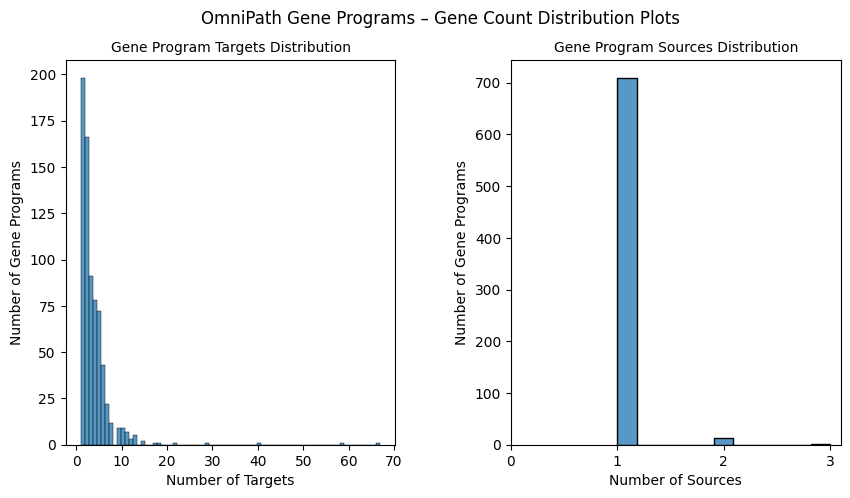

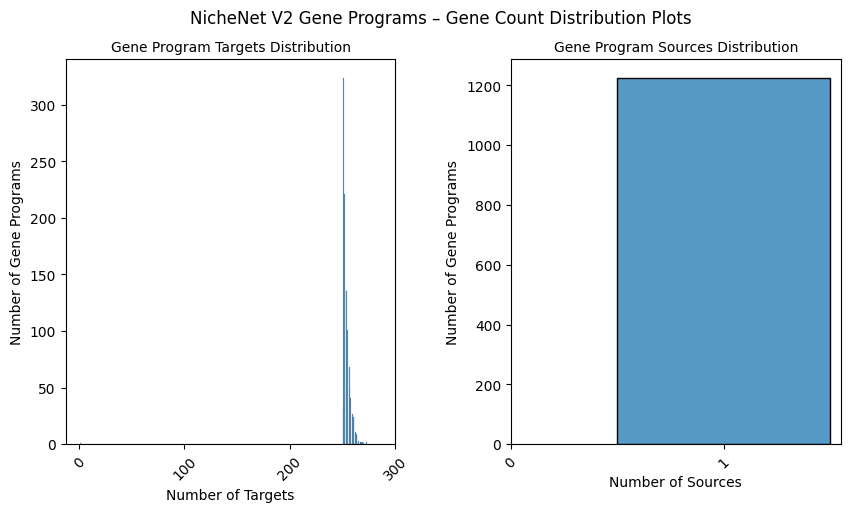

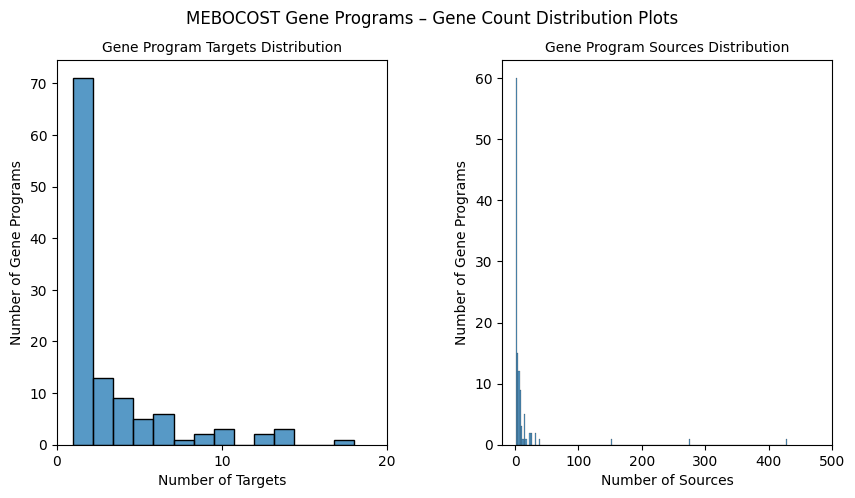

Combining ACE2_ligand_receptor_GP and ACE2_ligand_receptor_target_gene_GP.
Combining ADCYAP1_ligand_receptor_GP and ADCYAP1_ligand_receptor_target_gene_GP.
Combining ADGRE5_ligand_receptor_GP and ADGRE5_ligand_receptor_target_gene_GP.
Combining ADIPOQ_ligand_receptor_GP and ADIPOQ_ligand_receptor_target_gene_GP.
Combining ADM_ligand_receptor_GP and ADM_ligand_receptor_target_gene_GP.
Combining ADM2_ligand_receptor_GP and ADM2_ligand_receptor_target_gene_GP.
Combining AGRP_ligand_receptor_GP and AGRP_ligand_receptor_target_gene_GP.
Combining AGT_ligand_receptor_GP and AGT_ligand_receptor_target_gene_GP.
Combining ALCAM_ligand_receptor_GP and ALCAM_ligand_receptor_target_gene_GP.
Combining ALKAL1_ligand_receptor_GP and ALKAL1_ligand_receptor_target_gene_GP.
Combining ALKAL2_ligand_receptor_GP and ALKAL2_ligand_receptor_target_gene_GP.
Combining AMBN_ligand_receptor_GP and AMBN_ligand_receptor_target_gene_GP.
Combining AMELX_ligand_receptor_GP and AMELX_ligand_receptor_target_gene_GP.
Com

In [6]:
# Retrieve OmniPath GPs (source: ligand genes; target: receptor genes)
omnipath_gp_dict = extract_gp_dict_from_omnipath_lr_interactions(
    species=species,
    load_from_disk=False,
    save_to_disk=True,
    lr_network_file_path=omnipath_lr_network_file_path,
    gene_orthologs_mapping_file_path=gene_orthologs_mapping_file_path,
    plot_gp_gene_count_distributions=True,
    gp_gene_count_distributions_save_path=f"{figure_folder_path}" \
                                           "/omnipath_gp_gene_count_distributions.pdf")

# Display example OmniPath GP
omnipath_gp_names = list(omnipath_gp_dict.keys())
random.shuffle(omnipath_gp_names)
omnipath_gp_name = omnipath_gp_names[0]
# print(f"{omnipath_gp_name}: {omnipath_gp_dict[omnipath_gp_name]}")

# Retrieve NicheNet GPs (source: ligand genes; target: receptor genes, target genes)
nichenet_gp_dict = extract_gp_dict_from_nichenet_lrt_interactions(
    species=species,
    version="v2",
    keep_target_genes_ratio=1.,
    max_n_target_genes_per_gp=250,
    load_from_disk=True,
    save_to_disk=True,
    lr_network_file_path=nichenet_lr_network_file_path,
    ligand_target_matrix_file_path=nichenet_ligand_target_matrix_file_path,
    gene_orthologs_mapping_file_path=gene_orthologs_mapping_file_path,
    plot_gp_gene_count_distributions=True)

# Display example NicheNet GP
nichenet_gp_names = list(nichenet_gp_dict.keys())
random.shuffle(nichenet_gp_names)
nichenet_gp_name = nichenet_gp_names[0]
#print(f"{nichenet_gp_name}: {nichenet_gp_dict[nichenet_gp_name]}")

# Retrieve MEBOCOST GPs (source: enzyme genes; target: sensor genes)
mebocost_gp_dict = extract_gp_dict_from_mebocost_ms_interactions(
    dir_path=mebocost_enzyme_sensor_interactions_folder_path,
    species=species,
    plot_gp_gene_count_distributions=True)

# Display example MEBOCOST GP
mebocost_gp_names = list(mebocost_gp_dict.keys())
random.shuffle(mebocost_gp_names)
mebocost_gp_name = mebocost_gp_names[0]
# print(f"{mebocost_gp_name}: {mebocost_gp_dict[mebocost_gp_name]}")

# Filter and combine GPs
gp_dicts = [omnipath_gp_dict, nichenet_gp_dict, mebocost_gp_dict]
combined_gp_dict = filter_and_combine_gp_dict_gps_v2(
    gp_dicts,
    verbose=True)

### 2.2 Load Data & Compute Spatial Neighbor Graph

- NicheCompass expects a precomputed spatial adjacency matrix stored in 'adata.obsp[adj_key]'.
- The user can customize the spatial neighbor graph construction based on the biological question of interest.
- In the sample integration setting, we will compute a separate spatial adjacency matrix for each sample and combine them as disconnected components.

In [7]:
so_data_folder_path

'/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/data/CalculateCells/SelectCells/H5AD'

In [8]:
# Read data
adata = sc.read_h5ad(
        f"{so_data_folder_path}/SeuratObj_y31.h5ad")
adata.layers['counts'] = adata.X.copy()
adata.obsm['spatial'] = adata.obsm['X_cod']
#adata.var.set_index('SYMBOL', inplace=True) 

# Compute spatial neighborhood
sq.gr.spatial_neighbors(adata,
                        coord_type="generic",
                        spatial_key=spatial_key,
                        n_neighs=n_neighbors)

# Make adjacency matrix symmetric
adata.obsp[adj_key] = (
    adata.obsp[adj_key].maximum(
        adata.obsp[adj_key].T))

### 2.3 Add GP Mask to Data

In [9]:
# Add the GP dictionary as binary masks to the adata
add_gps_from_gp_dict_to_adata(
    gp_dict=combined_gp_dict,
    adata=adata,
    gp_targets_mask_key=gp_targets_mask_key,
    gp_targets_categories_mask_key=gp_targets_categories_mask_key,
    gp_sources_mask_key=gp_sources_mask_key,
    gp_sources_categories_mask_key=gp_sources_categories_mask_key,
    gp_names_key=gp_names_key,
    min_genes_per_gp=2,
    min_source_genes_per_gp=1,
    min_target_genes_per_gp=1,
    max_genes_per_gp=None,
    max_source_genes_per_gp=None,
    max_target_genes_per_gp=None)

### 2.4 Explore Data (annotation need!!!)

In [11]:
adata

AnnData object with n_obs × n_vars = 246918 × 29003
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_Spatial', 'nFeature_Spatial', 'cell', 'x', 'y'
    var: 'name'
    uns: 'spatial_neighbors', 'nichecompass_sources_categories_label_encoder', 'nichecompass_targets_categories_label_encoder', 'nichecompass_source_genes_idx', 'nichecompass_target_genes_idx', 'nichecompass_genes_idx', 'nichecompass_gp_names'
    obsm: 'X_cod', 'spatial'
    varm: 'nichecompass_gp_sources', 'nichecompass_gp_targets', 'nichecompass_gp_sources_categories', 'nichecompass_gp_targets_categories'
    layers: 'counts'
    obsp: 'spatial_connectivities', 'spatial_distances'

## 3. Train Model

### 3.1 Initialize, Train & Save Model

In [10]:
# Initialize model
model = NicheCompass(adata,
                     counts_key=counts_key,
                     adj_key=adj_key,
                     gp_names_key=gp_names_key,
                     active_gp_names_key=active_gp_names_key,
                     gp_targets_mask_key=gp_targets_mask_key,
                     gp_targets_categories_mask_key=gp_targets_categories_mask_key,
                     gp_sources_mask_key=gp_sources_mask_key,
                     gp_sources_categories_mask_key=gp_sources_categories_mask_key,
                     latent_key=latent_key,
                     conv_layer_encoder=conv_layer_encoder,
                     active_gp_thresh_ratio=active_gp_thresh_ratio)

--- INITIALIZING NEW NETWORK MODULE: VARIATIONAL GENE PROGRAM GRAPH AUTOENCODER ---
LOSS -> include_edge_recon_loss: True, include_gene_expr_recon_loss: True, rna_recon_loss: nb
NODE LABEL METHOD -> one-hop-norm
ACTIVE GP THRESHOLD RATIO -> 0.01
LOG VARIATIONAL -> True
ONE HOP GCN NORM RNA NODE LABEL AGGREGATOR
ENCODER -> n_input: 29003, n_cat_covariates_embed_input: 0, n_hidden: 1459, n_latent: 1359, n_addon_latent: 100, n_fc_layers: 1, n_layers: 1, conv_layer: gcnconv, n_attention_heads: 0, dropout_rate: 0.0, 
COSINE SIM GRAPH DECODER -> dropout_rate: 0.0
MASKED TARGET RNA DECODER -> n_prior_gp_input: 1359, n_addon_gp_input: 100, n_cat_covariates_embed_input: 0, n_output: 29003
MASKED SOURCE RNA DECODER -> n_prior_gp_input: 1359, n_addon_gp_input: 100, n_cat_covariates_embed_input: 0, n_output: 29003


In [11]:
# Train model
model.train(n_epochs=n_epochs,
            n_epochs_all_gps=n_epochs_all_gps,
            lr=lr,
            lambda_edge_recon=lambda_edge_recon,
            lambda_gene_expr_recon=lambda_gene_expr_recon,
            lambda_l1_masked=lambda_l1_masked,
            edge_batch_size=edge_batch_size,
            n_sampled_neighbors=n_sampled_neighbors,
            use_cuda_if_available=use_cuda_if_available,
            verbose=False)


--- INITIALIZING TRAINER ---
Number of training nodes: 222226
Number of validation nodes: 24692
Number of training edges: 445862
Number of validation edges: 49540
Edge batch size: 1024
Node batch size: None

--- MODEL TRAINING ---
Epoch 1/100 |--------------------| 1.0% train_global_loss: 1899732.6402; train_optim_loss: 1899732.6402; val_global_loss: 1288783.9184; val_optim_loss: 1288783.9184
Epoch 2/100 |--------------------| 2.0% train_global_loss: 1263465.6385; train_optim_loss: 1263465.6385; val_global_loss: 1254211.1199; val_optim_loss: 1254211.1199
Epoch 3/100 |--------------------| 3.0% train_global_loss: 1238116.6112; train_optim_loss: 1238116.6112; val_global_loss: 1234327.2934; val_optim_loss: 1234327.2934
Epoch 4/100 |--------------------| 4.0% train_global_loss: 1219587.5513; train_optim_loss: 1219587.5513; val_global_loss: 1218531.2959; val_optim_loss: 1218531.2959
Epoch 5/100 |█-------------------| 5.0% train_global_loss: 1206348.7950; train_optim_loss: 1206348.7950; val

In [12]:
# Compute latent neighbor graph
sc.pp.neighbors(model.adata,
                use_rep=latent_key,
                key_added=latent_key)

# Compute UMAP embedding
sc.tl.umap(model.adata,
           neighbors_key=latent_key)

In [13]:
# Save trained model
model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="adata.h5ad")

## 4. Analysis

In [14]:
load_timestamp = current_timestamp
# load_timestamp = current_timestamp # uncomment if you trained the model in this notebook

figure_folder_path = f"../../artifacts/{dataset}/figures/single_sample/{load_timestamp}"
model_folder_path = f"../../artifacts/{dataset}/models/single_sample/{load_timestamp}"
result_folder_path = f"../../artifacts/{dataset}/results/single_sample/{load_timestamp}"

os.makedirs(figure_folder_path, exist_ok=True)

In [7]:
# Load trained model
model = NicheCompass.load(dir_path=model_folder_path,
                          adata=None,
                          adata_file_name="adata.h5ad",
                          gp_names_key=gp_names_key)

--- INITIALIZING NEW NETWORK MODULE: VARIATIONAL GENE PROGRAM GRAPH AUTOENCODER ---
LOSS -> include_edge_recon_loss: True, include_gene_expr_recon_loss: True, rna_recon_loss: nb
NODE LABEL METHOD -> one-hop-norm
ACTIVE GP THRESHOLD RATIO -> 0.01
LOG VARIATIONAL -> True
CATEGORICAL COVARIATES EMBEDDINGS INJECTION -> ['gene_expr_decoder']
ONE HOP GCN NORM RNA NODE LABEL AGGREGATOR
ENCODER -> n_input: 30322, n_cat_covariates_embed_input: 0, n_hidden: 1454, n_latent: 1354, n_addon_latent: 100, n_fc_layers: 1, n_layers: 1, conv_layer: gcnconv, n_attention_heads: 0, dropout_rate: 0.0, 
COSINE SIM GRAPH DECODER -> dropout_rate: 0.0
MASKED TARGET RNA DECODER -> n_prior_gp_input: 1354, n_addon_gp_input: 100, n_cat_covariates_embed_input: 3, n_output: 30322
MASKED SOURCE RNA DECODER -> n_prior_gp_input: 1354, n_addon_gp_input: 100, n_cat_covariates_embed_input: 3, n_output: 30322


### 4.2 Identify Niches

We compute Leiden clustering of the NicheCompass latent GP space to identify spatially consistent cell niches.

In [23]:
model.adata

AnnData object with n_obs × n_vars = 8253 × 25274
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_Spatial', 'nFeature_Spatial', 'cell', 'x', 'y'
    var: 'name'
    uns: 'spatial_neighbors', 'nichecompass_sources_categories_label_encoder', 'nichecompass_targets_categories_label_encoder', 'nichecompass_source_genes_idx', 'nichecompass_target_genes_idx', 'nichecompass_genes_idx', 'nichecompass_gp_names', 'nichecompass_active_gp_names', 'nichecompass_latent', 'umap'
    obsm: 'X_cod', 'spatial', 'nichecompass_latent', 'X_umap'
    varm: 'nichecompass_gp_sources', 'nichecompass_gp_targets', 'nichecompass_gp_sources_categories', 'nichecompass_gp_targets_categories'
    layers: 'counts'
    obsp: 'spatial_connectivities', 'spatial_distances', 'nichecompass_latent_distances', 'nichecompass_latent_connectivities'

In [15]:
latent_leiden_resolution = 0.3
# Compute latent Leiden clustering
sc.tl.leiden(adata=model.adata,
             resolution=latent_leiden_resolution,
             key_added=latent_cluster_key,
             neighbors_key=latent_key)
latent_cluster_colors = create_new_color_dict(
    adata=model.adata,
    cat_key=latent_cluster_key)

samples = ['y31']
model.adata.obs[sample_key] = "y31"

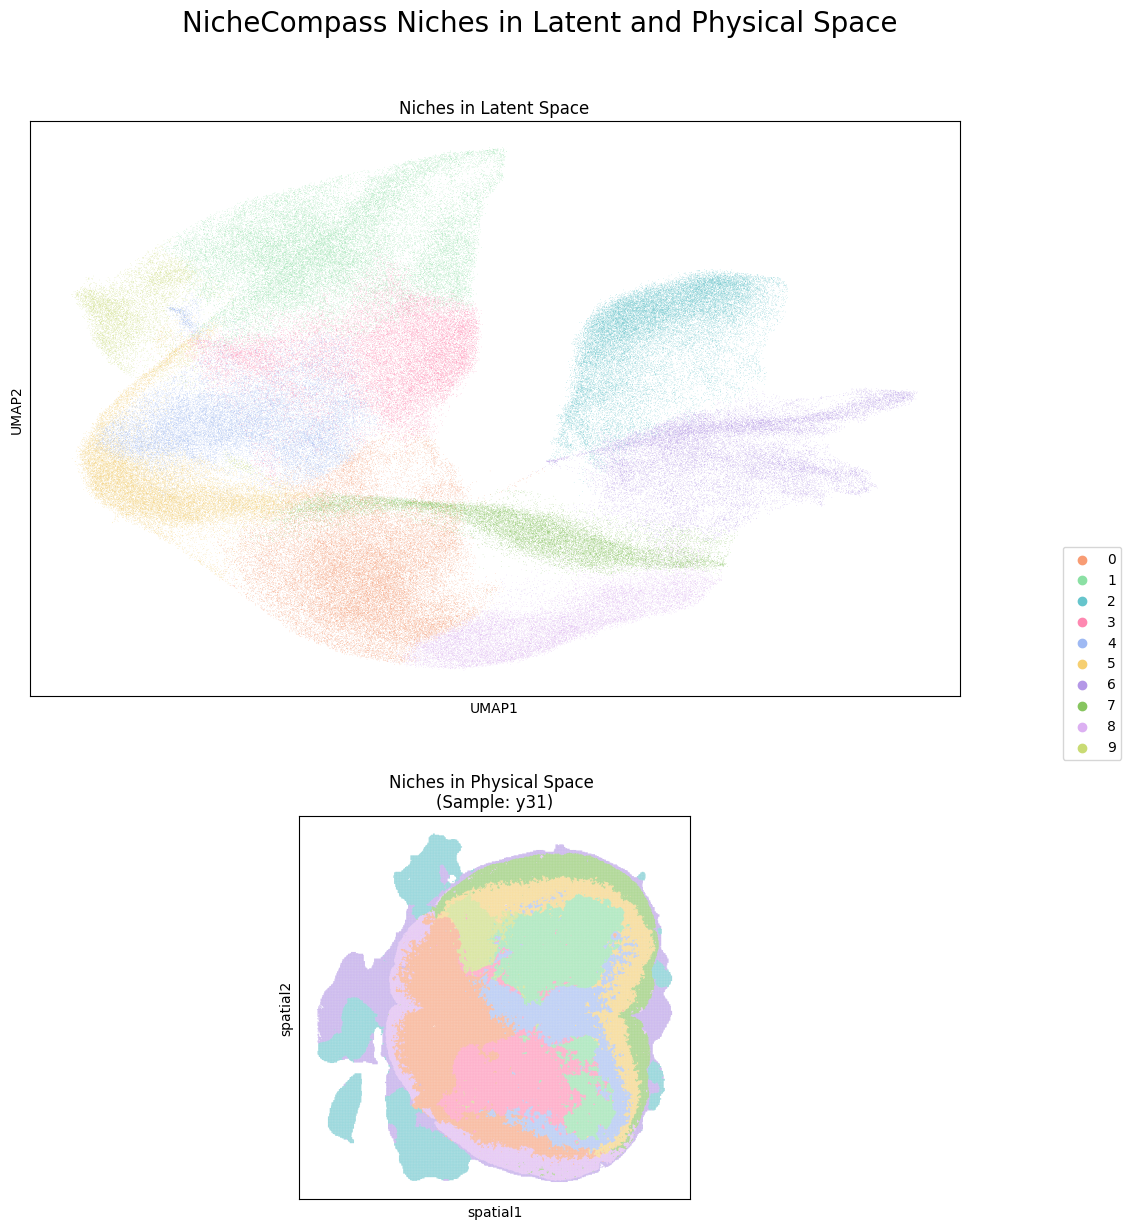

In [16]:
# Create plot of latent cluster / niche annotations in physical and latent space
groups = None # set this to a specific cluster for easy visualization, e.g. ["17"]
save_fig = True
file_path = f"{figure_folder_path}/" \
            f"res_{latent_leiden_resolution}_" \
            "niches_latent_physical_space.pdf"

fig = plt.figure(figsize=(12, 14))
title = fig.suptitle(t=f"NicheCompass Niches " \
                       "in Latent and Physical Space",
                     y=0.96,
                     x=0.55,
                     fontsize=20)
spec1 = gridspec.GridSpec(ncols=1,
                          nrows=2,
                          width_ratios=[1],
                          height_ratios=[3, 2])
spec2 = gridspec.GridSpec(ncols=len(samples),
                          nrows=2,
                          width_ratios=[1] * len(samples),
                          height_ratios=[3, 2])
axs = []
axs.append(fig.add_subplot(spec1[0]))
sc.pl.umap(adata=model.adata,
           color=[latent_cluster_key],
           groups=groups,
           palette=latent_cluster_colors,
           title=f"Niches in Latent Space",
           ax=axs[0],
           show=False)
for idx, sample in enumerate(samples):
    axs.append(fig.add_subplot(spec2[len(samples) + idx]))
    sc.pl.spatial(adata=model.adata[model.adata.obs[sample_key] == sample],
                  color=[latent_cluster_key],
                  groups=groups,
                  palette=latent_cluster_colors,
                  spot_size=spot_size,
                  title=f"Niches in Physical Space \n"
                        f"(Sample: {sample})",
                  legend_loc=None,
                  ax=axs[idx+1],
                  show=False)

# Create and position shared legend
handles, labels = axs[0].get_legend_handles_labels()
lgd = fig.legend(handles,
                 labels,
                 loc="center left",
                 bbox_to_anchor=(0.98, 0.5))
axs[0].get_legend().remove()

# Adjust, save and display plot
plt.subplots_adjust(wspace=0.2, hspace=0.25)
if save_fig:
    fig.savefig(file_path,
                bbox_extra_artists=(lgd, title),
                bbox_inches="tight",
                format="pdf")  # 关键参数
plt.show()

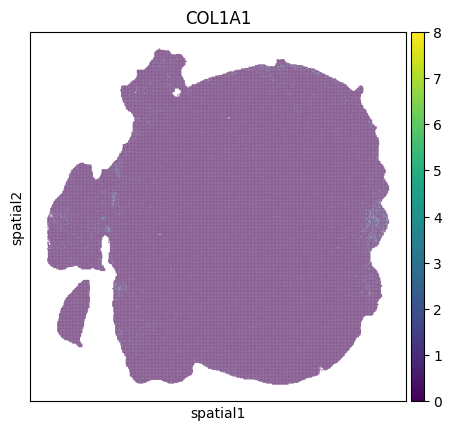

In [17]:
sc.pl.spatial(adata=model.adata[model.adata.obs[sample_key] == sample],
                  color=['COL1A1'],
                  spot_size=30,
            )

### 4.2x subset model.adata by niche

In [18]:
model.adata

AnnData object with n_obs × n_vars = 246918 × 29003
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_Spatial', 'nFeature_Spatial', 'cell', 'x', 'y', 'latent_leiden_0.3', 'batch'
    var: 'name'
    uns: 'spatial_neighbors', 'nichecompass_sources_categories_label_encoder', 'nichecompass_targets_categories_label_encoder', 'nichecompass_source_genes_idx', 'nichecompass_target_genes_idx', 'nichecompass_genes_idx', 'nichecompass_gp_names', 'nichecompass_active_gp_names', 'nichecompass_latent', 'umap', 'leiden', 'latent_leiden_0.3_colors'
    obsm: 'X_cod', 'spatial', 'nichecompass_latent', 'X_umap'
    varm: 'nichecompass_gp_sources', 'nichecompass_gp_targets', 'nichecompass_gp_sources_categories', 'nichecompass_gp_targets_categories'
    layers: 'counts'
    obsp: 'spatial_connectivities', 'spatial_distances', 'nichecompass_latent_distances', 'nichecompass_latent_connectivities'

In [19]:
latent_cluster_key

'latent_leiden_0.3'

In [20]:
model.adata.obs.head()

,nCount_RNA,nFeature_RNA,nCount_Spatial,nFeature_Spatial,cell,x,y,latent_leiden_0.3,batch
Y31:8400_6060,503.0,285,503.0,285,Y31:8400_6060,8400.0,6060.0,2,y31
Y31:17550_18960,179.0,109,179.0,109,Y31:17550_18960,17550.0,18960.0,5,y31
Y31:14040_18510,416.0,234,416.0,234,Y31:14040_18510,14040.0,18510.0,0,y31
Y31:17220_5640,1626.0,799,1626.0,799,Y31:17220_5640,17220.0,5640.0,5,y31
Y31:7920_15120,334.0,189,334.0,189,Y31:7920_15120,7920.0,15120.0,8,y31


In [21]:
# 计算每个leiden分群的平均nCount_Spatial值
mean_counts = adata.obs.groupby('latent_leiden_0.3')['nCount_Spatial'].mean()

# 查看结果
print(mean_counts)

latent_leiden_0.3
0    186.612494
1    687.723196
2    307.544851
3    298.928883
4    298.039624
5    450.334148
6    350.072854
7    723.692288
8    391.995961
9    647.663432
Name: nCount_Spatial, dtype: float64


In [22]:
selected_indices = model.adata.obs['latent_leiden_0.3'].isin(['0', '1', '3', '4', '5', '7', '8', '9'])

# 获取对应的x,y坐标
selected_coords = model.adata.obs.loc[selected_indices, ['x', 'y']]

In [23]:
selected_coords.head()

,x,y
Y31:17550_18960,17550.0,18960.0
Y31:14040_18510,14040.0,18510.0
Y31:17220_5640,17220.0,5640.0
Y31:7920_15120,7920.0,15120.0
Y31:13350_4470,13350.0,4470.0


In [27]:
selected_coords.to_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/data/CalculateCells/nichecompass/artifacts/stereo_seq_spinal_cord_y31/results/single_sample/08092025_202805/Barcode_selected_by_niche_y31.csv')

当前文档只用于筛选，到这就结束了

### 4.3 Characterize Niches

Now we will characterize the identified cell niches.

#### 4.3.1 Differential GPs

Now we can test which GPs are differentially expressed in a niche. To this end, we will perform "one-vs-rest" differential GP testing, i.e all niches (```selected_cats = None```) are tested against all other niches (```comparison_cats = "rest"```). However, differential GP testing can also be performed in the following ways:
- Set ```selected_cats = ["0"]``` to perform differential GP testing for a specific niche only, in this case niche "0".
- Set ```comparison_cats = ["2"]``` to perform differential GP testing against niche "2" as opposed to against all other niches.

We choose an absolute log bayes factor threshold of 2.3 to determine strongly enriched GPs (see https://en.wikipedia.org/wiki/Bayes_factor).

In [10]:
# Check number of active GPs
active_gps = model.get_active_gps()
print(f"Number of total gene programs: {len(model.adata.uns[gp_names_key])}.")
print(f"Number of active gene programs: {len(active_gps)}.")

Number of total gene programs: 1454.
Number of active gene programs: 1219.


In [11]:
# Display example active GPs
gp_summary_df = model.get_gp_summary()
gp_summary_df[gp_summary_df["gp_active"] == True].head()

,gp_name,all_gp_idx,gp_active,active_gp_idx,n_source_genes,n_non_zero_source_genes,n_target_genes,n_non_zero_target_genes,gp_source_genes,gp_target_genes,gp_source_genes_weights,gp_target_genes_weights,gp_source_genes_importances,gp_target_genes_importances
0,ACTR2_ligand_receptor_GP,0,True,0,1,1,1,1,[ACTR2],[ACVR1B],[-0.253],[0.003],[0.9882],[0.0118]
1,AFDN_ligand_receptor_GP,1,True,1,1,1,10,10,[AFDN],"[EPHB6, EPHB3, NECTIN4, NECTIN1, EPHB2, NECTIN...",[-0.1442],"[0.0472, -0.0189, -0.0156, 0.0144, 0.0085, 0.0...",[0.5484],"[0.1795, 0.072, 0.0592, 0.0547, 0.0325, 0.0212..."
2,AGTRAP_ligand_receptor_GP,2,True,2,1,1,1,1,[AGTRAP],[RACK1],[0.0987],[-0.1531],[0.3921],[0.6079]
3,ARF4_ligand_receptor_GP,3,True,3,1,1,1,1,[ARF4],[EGFR],[0.4082],[-0.012],[0.9714],[0.0286]
4,ARF6_ligand_receptor_GP,4,True,4,1,1,5,5,[ARF6],"[PLD1, PIP5K1C, PIP5K1A, MAPK3, MAPK1]",[-1e-04],"[0.0479, 0.0244, 0.0157, -0.0109, -0.0065]",[0.0014],"[0.4541, 0.231, 0.1491, 0.1031, 0.0614]"


In [12]:
# Set parameters for differential gp testing
selected_cats = None
comparison_cats = "rest"
title = f"NicheCompass Strongly Enriched Niche GPs"
log_bayes_factor_thresh = 2.3
save_fig = True
file_path = f"{figure_folder_path}/" \
            f"/log_bayes_factor_{log_bayes_factor_thresh}" \
             "_niches_enriched_gps_heatmap.pdf"

In [13]:
# Run differential gp testing
enriched_gps = model.run_differential_gp_tests(
    cat_key=latent_cluster_key,
    selected_cats=selected_cats,
    comparison_cats=comparison_cats,
    log_bayes_factor_thresh=log_bayes_factor_thresh)

In [14]:
# Results are stored in a df in the adata object
differential_gp_test_results_frame = model.adata.uns[differential_gp_test_results_key]
differential_gp_test_results_frame

,category,gene_program,p_h0,p_h1,log_bayes_factor
0,6,WNT9B_combined_GP,0.996796,0.003204,5.740218
1,6,ADAM29_ligand_receptor_target_gene_GP,0.003535,0.996465,-5.641555
2,6,GAST_combined_GP,0.003575,0.996425,-5.630193
3,6,Histamine_metabolite_enzyme_sensor_GP,0.996359,0.003641,5.611954
4,6,EFNB3_combined_GP,0.004030,0.995970,-5.509943
...,...,...,...,...,...
1019,3,Myristic acid_metabolite_enzyme_sensor_GP,0.090550,0.909450,-2.306943
1020,6,SLITRK1_combined_GP,0.909393,0.090607,2.306243
1021,1,IFNK_combined_GP,0.909211,0.090789,2.304042
1022,3,ACP4_ligand_receptor_target_gene_GP,0.090840,0.909160,-2.303420


In [15]:
# 对数据框按category列分组，并选出每组中p_h0列最高的三行
top_rows_per_category = differential_gp_test_results_frame.groupby('category').apply(
    lambda group: group.nlargest(5, 'p_h0')
).reset_index(drop=True)

top_rows_per_category['gene_program']

/tmp/ipykernel_1217938/2323021327.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_rows_per_category = differential_gp_test_results_frame.groupby('category').apply(


0           Androstenedione_metabolite_enzyme_sensor_GP
1                 D-Glucose_metabolite_enzyme_sensor_GP
2                                       GRP_combined_GP
3                                     CD209_combined_GP
4                 Ornithine_metabolite_enzyme_sensor_GP
5                L-Arginine_metabolite_enzyme_sensor_GP
6                  TIMP1_ligand_receptor_target_gene_GP
7                           TNFRSF1B_ligand_receptor_GP
8                   PLB1_ligand_receptor_target_gene_GP
9                              FSTL1_ligand_receptor_GP
10                   COMPLEX:LTA_LTB_ligand_receptor_GP
11               COMPLEX:IL12A_IL12B_ligand_receptor_GP
12                             RPH3A_ligand_receptor_GP
13                             CD177_ligand_receptor_GP
14             Hypoxanthine_metabolite_enzyme_sensor_GP
15                             FGFR3_ligand_receptor_GP
16    Dihomo-gamma-linolenic acid_metabolite_enzyme_...
17                             PTPN6_ligand_rece

In [16]:
# Visualize GP activities of enriched GPs across niches
df = model.adata.obs[[latent_cluster_key] + enriched_gps].groupby(latent_cluster_key).mean()

scaler = MinMaxScaler()
normalized_columns = scaler.fit_transform(df)
normalized_df = pd.DataFrame(normalized_columns, columns=df.columns)
normalized_df.index = df.index

In [17]:
top5 = normalized_df[top_rows_per_category['gene_program'].to_list()]
top5

,Androstenedione_metabolite_enzyme_sensor_GP,D-Glucose_metabolite_enzyme_sensor_GP,GRP_combined_GP,CD209_combined_GP,Ornithine_metabolite_enzyme_sensor_GP,L-Arginine_metabolite_enzyme_sensor_GP,TIMP1_ligand_receptor_target_gene_GP,TNFRSF1B_ligand_receptor_GP,PLB1_ligand_receptor_target_gene_GP,FSTL1_ligand_receptor_GP,...,WNT9B_combined_GP,Histamine_metabolite_enzyme_sensor_GP,CD320_ligand_receptor_target_gene_GP,NTS_combined_GP,PVR_ligand_receptor_target_gene_GP,TIMD4_ligand_receptor_target_gene_GP,ORM1_combined_GP,CCL13_combined_GP,BTLA_ligand_receptor_target_gene_GP,ADAM10_ligand_receptor_target_gene_GP
latent_leiden_0.3,,,,,,,,,,,,,,,,,,,,,
0,1.000000,1.000000,1.000000,1.000000,1.000000,0.392256,0.596559,0.321240,0.528687,0.572136,...,0.327349,0.256028,0.171795,0.382217,0.384623,0.684409,0.519788,0.664108,0.707022,0.773559
1,0.530628,0.529006,0.438056,0.482544,0.472169,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.143933,0.264561,0.099994,0.039116,0.724021,0.496026,0.716198,0.549545,0.711158
2,0.467425,0.450089,0.527115,0.573764,0.447007,0.000000,0.039764,0.029572,0.054964,0.056426,...,0.479234,0.409097,0.192202,0.295827,0.379429,0.659919,0.671005,0.671719,0.703229,0.591505
3,0.000000,0.000000,0.043104,0.000000,0.000000,0.480703,0.400389,0.510476,0.314660,0.496586,...,0.509123,0.648281,0.542646,0.434522,0.302019,0.346730,0.219305,0.402219,0.051769,0.139440
4,0.279214,0.254276,0.435031,0.428156,0.531833,0.414931,0.171617,0.389686,0.292184,0.486706,...,0.697995,0.621613,0.657465,0.555971,0.430144,0.155827,0.050961,0.409932,0.000000,0.000000
5,0.115337,0.112198,0.000000,0.108960,0.059626,0.421362,0.418553,0.534592,0.430331,0.376493,...,0.171064,0.286410,0.213095,0.146791,0.032370,0.728386,0.791531,0.809272,0.568087,0.620397
6,0.356539,0.260908,0.496060,0.463899,0.516894,0.092494,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.118892,0.105229
7,0.732358,0.722476,0.636553,0.687628,0.559670,0.403972,0.605634,0.455476,0.591704,0.458526,...,0.006700,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### 4.3.2 Ncihe annotation

In [18]:
# annotation from 4.3.2 Differential GPs!!! calculate and back here.
niche_annotation_dict = {
    "0":"GRP/CD209+ Ventral_Horn",    
    "1":"TNFRSF1B/CD300LF+ Intermediate Gray",
    "2":"IL12A/RPH3A+ Mesoderm", 
    "3":"PTPN6/CLCF1+ Peripheral_VZ",
    "4":"CDH1/MAPT+ Inner_VZ",
    "5":"CD200R1/NPY+ Dorsal_Horn",
    "6":"WNT9B/PVR+ Floor_Plate",
    "7":"TIMD4/ORM1+ Lateral_Horn"}

model.adata.obs["niche"] = model.adata.obs[latent_cluster_key].map(niche_annotation_dict)

In [19]:
latent_cluster_colors = {
    'PTPN6/CLCF1+ Peripheral_VZ': '#FF7F50',  
    'CDH1/MAPT+ Inner_VZ': '#FFD700',     
    'TNFRSF1B/CD300LF+ Intermediate Gray': '#4682B4', 
    'GRP/CD209+ Ventral_Horn': '#9370DB',    
    'CD200R1/NPY+ Dorsal_Horn': '#CD5C5C',    
    'IL12A/RPH3A+ Mesoderm': '#8FBC8F',      
    'WNT9B/PVR+ Floor_Plate': '#7AC5CD',      
    'TIMD4/ORM1+ Lateral_Horn': '#DCB0F2',   
    '-1': '#DCDCDC'                          
}

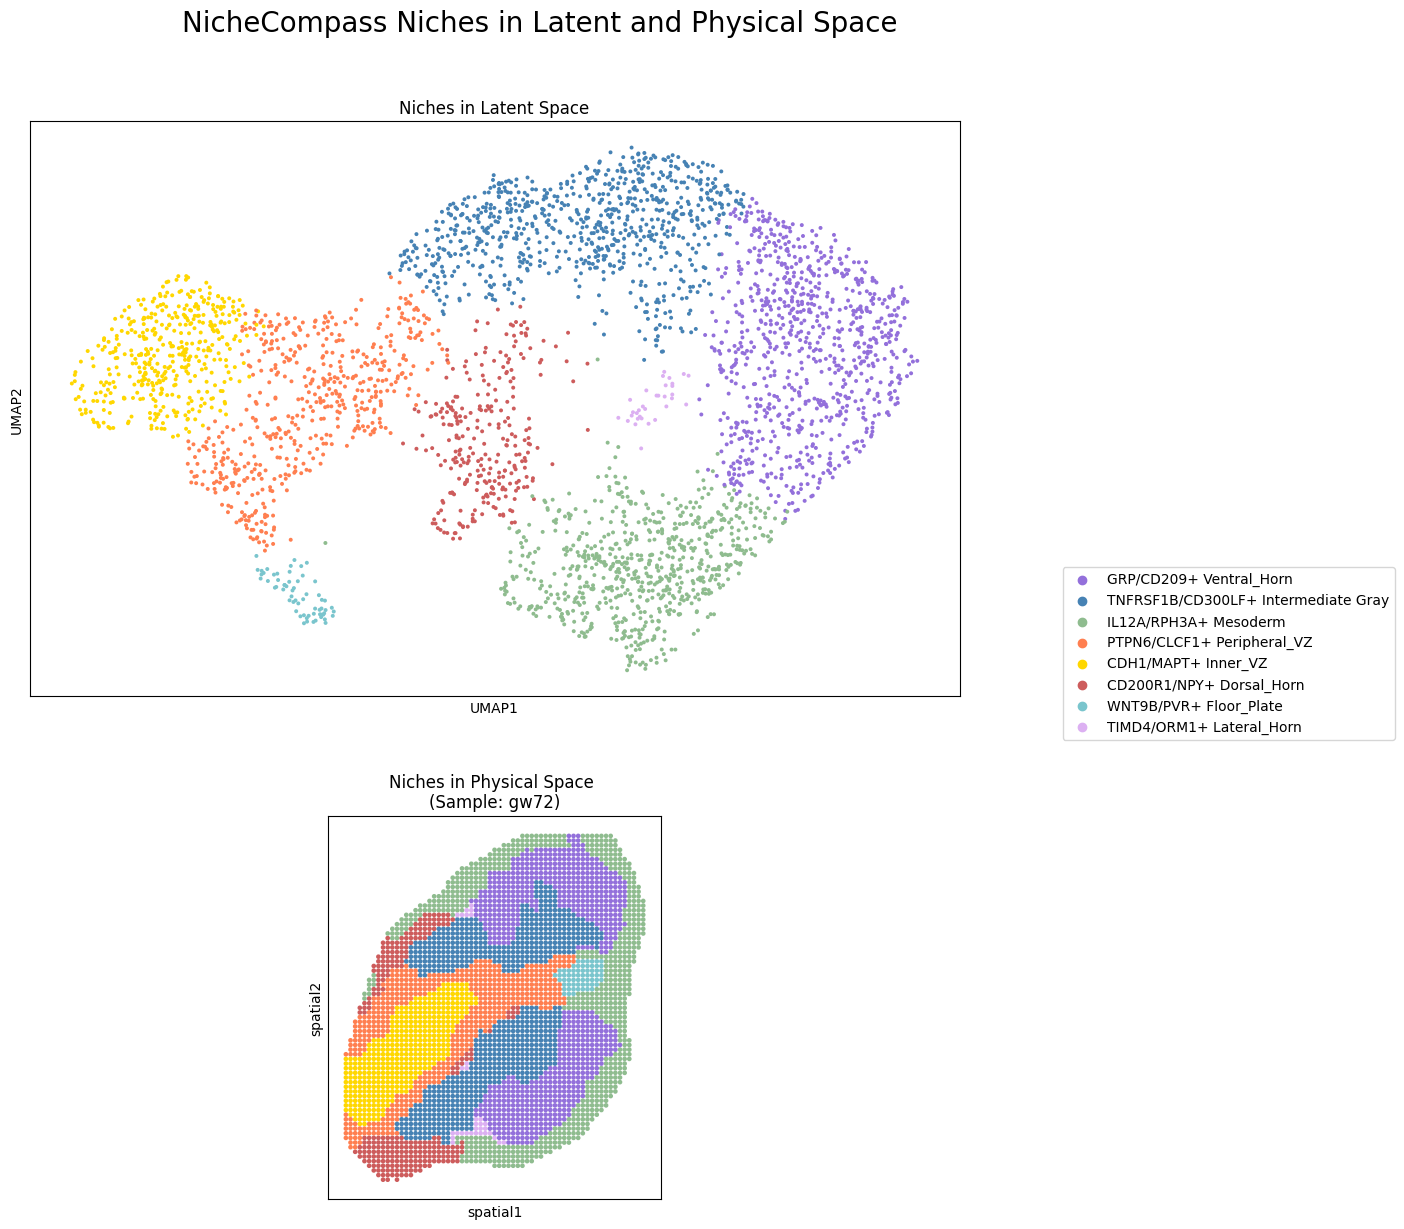

In [20]:
# Create plot of latent cluster / niche annotations in physical and latent space
groups = None # set this to a specific cluster for easy visualization, e.g. ["17"]
save_fig = True
file_path = f"{figure_folder_path}/" \
            f"res_{latent_leiden_resolution}_" \
            "niches_latent_physical_space.pdf"

fig = plt.figure(figsize=(12, 14))
title = fig.suptitle(t=f"NicheCompass Niches " \
                       "in Latent and Physical Space",
                     y=0.96,
                     x=0.55,
                     fontsize=20)
spec1 = gridspec.GridSpec(ncols=1,
                          nrows=2,
                          width_ratios=[1],
                          height_ratios=[3, 2])
spec2 = gridspec.GridSpec(ncols=len(samples),
                          nrows=2,
                          width_ratios=[1] * len(samples),
                          height_ratios=[3, 2])
axs = []
axs.append(fig.add_subplot(spec1[0]))
sc.pl.umap(adata=model.adata,
           color=["niche"],
           groups=groups,
           palette=latent_cluster_colors,
           title=f"Niches in Latent Space",
           ax=axs[0],
           show=False)
for idx, sample in enumerate(samples):
    axs.append(fig.add_subplot(spec2[len(samples) + idx]))
    sc.pl.spatial(adata=model.adata[model.adata.obs[sample_key] == sample],
                  color=["niche"],
                  groups=groups,
                  palette=latent_cluster_colors,
                  spot_size=spot_size,
                  title=f"Niches in Physical Space \n"
                        f"(Sample: {sample})",
                  legend_loc=None,
                  ax=axs[idx+1],
                  show=False)

# Create and position shared legend
handles, labels = axs[0].get_legend_handles_labels()
lgd = fig.legend(handles,
                 labels,
                 loc="center left",
                 bbox_to_anchor=(0.98, 0.5))
axs[0].get_legend().remove()

# Adjust, save and display plot
plt.subplots_adjust(wspace=0.2, hspace=0.25)
if save_fig:
    fig.savefig(file_path,
                bbox_extra_artists=(lgd, title),
                bbox_inches="tight")
plt.show()

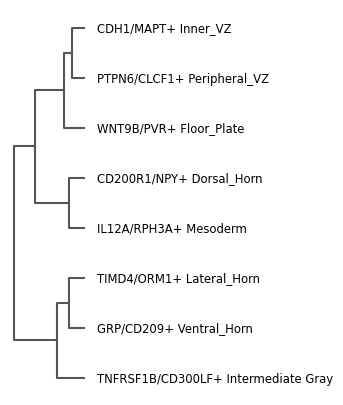

In [22]:
# dendrogram
sc.tl.dendrogram(adata=model.adata,
                 use_rep="nichecompass_latent",
                 linkage_method="ward",
                 groupby="niche")

fig, (ax) = plt.subplots(1, 1, figsize=(1, 5))
sc.pl.dendrogram(
    adata=model.adata,
    groupby="niche",
    orientation="left",
    ax=ax)
plt.show()

file_path = f"{figure_folder_path}/" \
            f"res_{latent_leiden_resolution}_" \
            "dendrogram_nichecompass_latent.pdf"
fig.savefig(file_path)

#### 4.3.3 Niche Composition

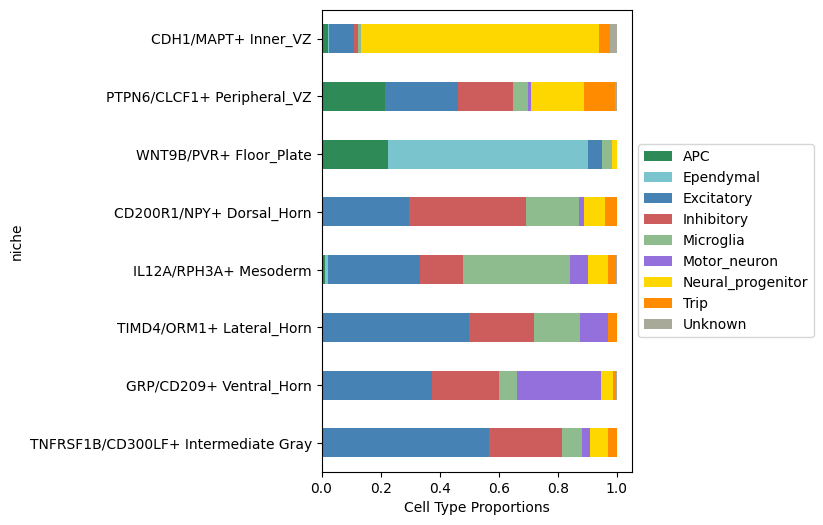

In [26]:
# scaled niche_cell_type_proportions
tmp = pd.crosstab(model.adata.obs["niche"], model.adata.obs[cell_type_key], normalize='index')
tmp = tmp.reindex(model.adata.uns["dendrogram_niche"]["categories_ordered"][::])
ax = tmp.plot.barh(color=cell_type_colors, stacked=True, figsize=(4, 6)).legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.xlabel("Cell Type Proportions")
plt.savefig(f"{figure_folder_path}/niche_cell_type_proportions.pdf", bbox_inches='tight')

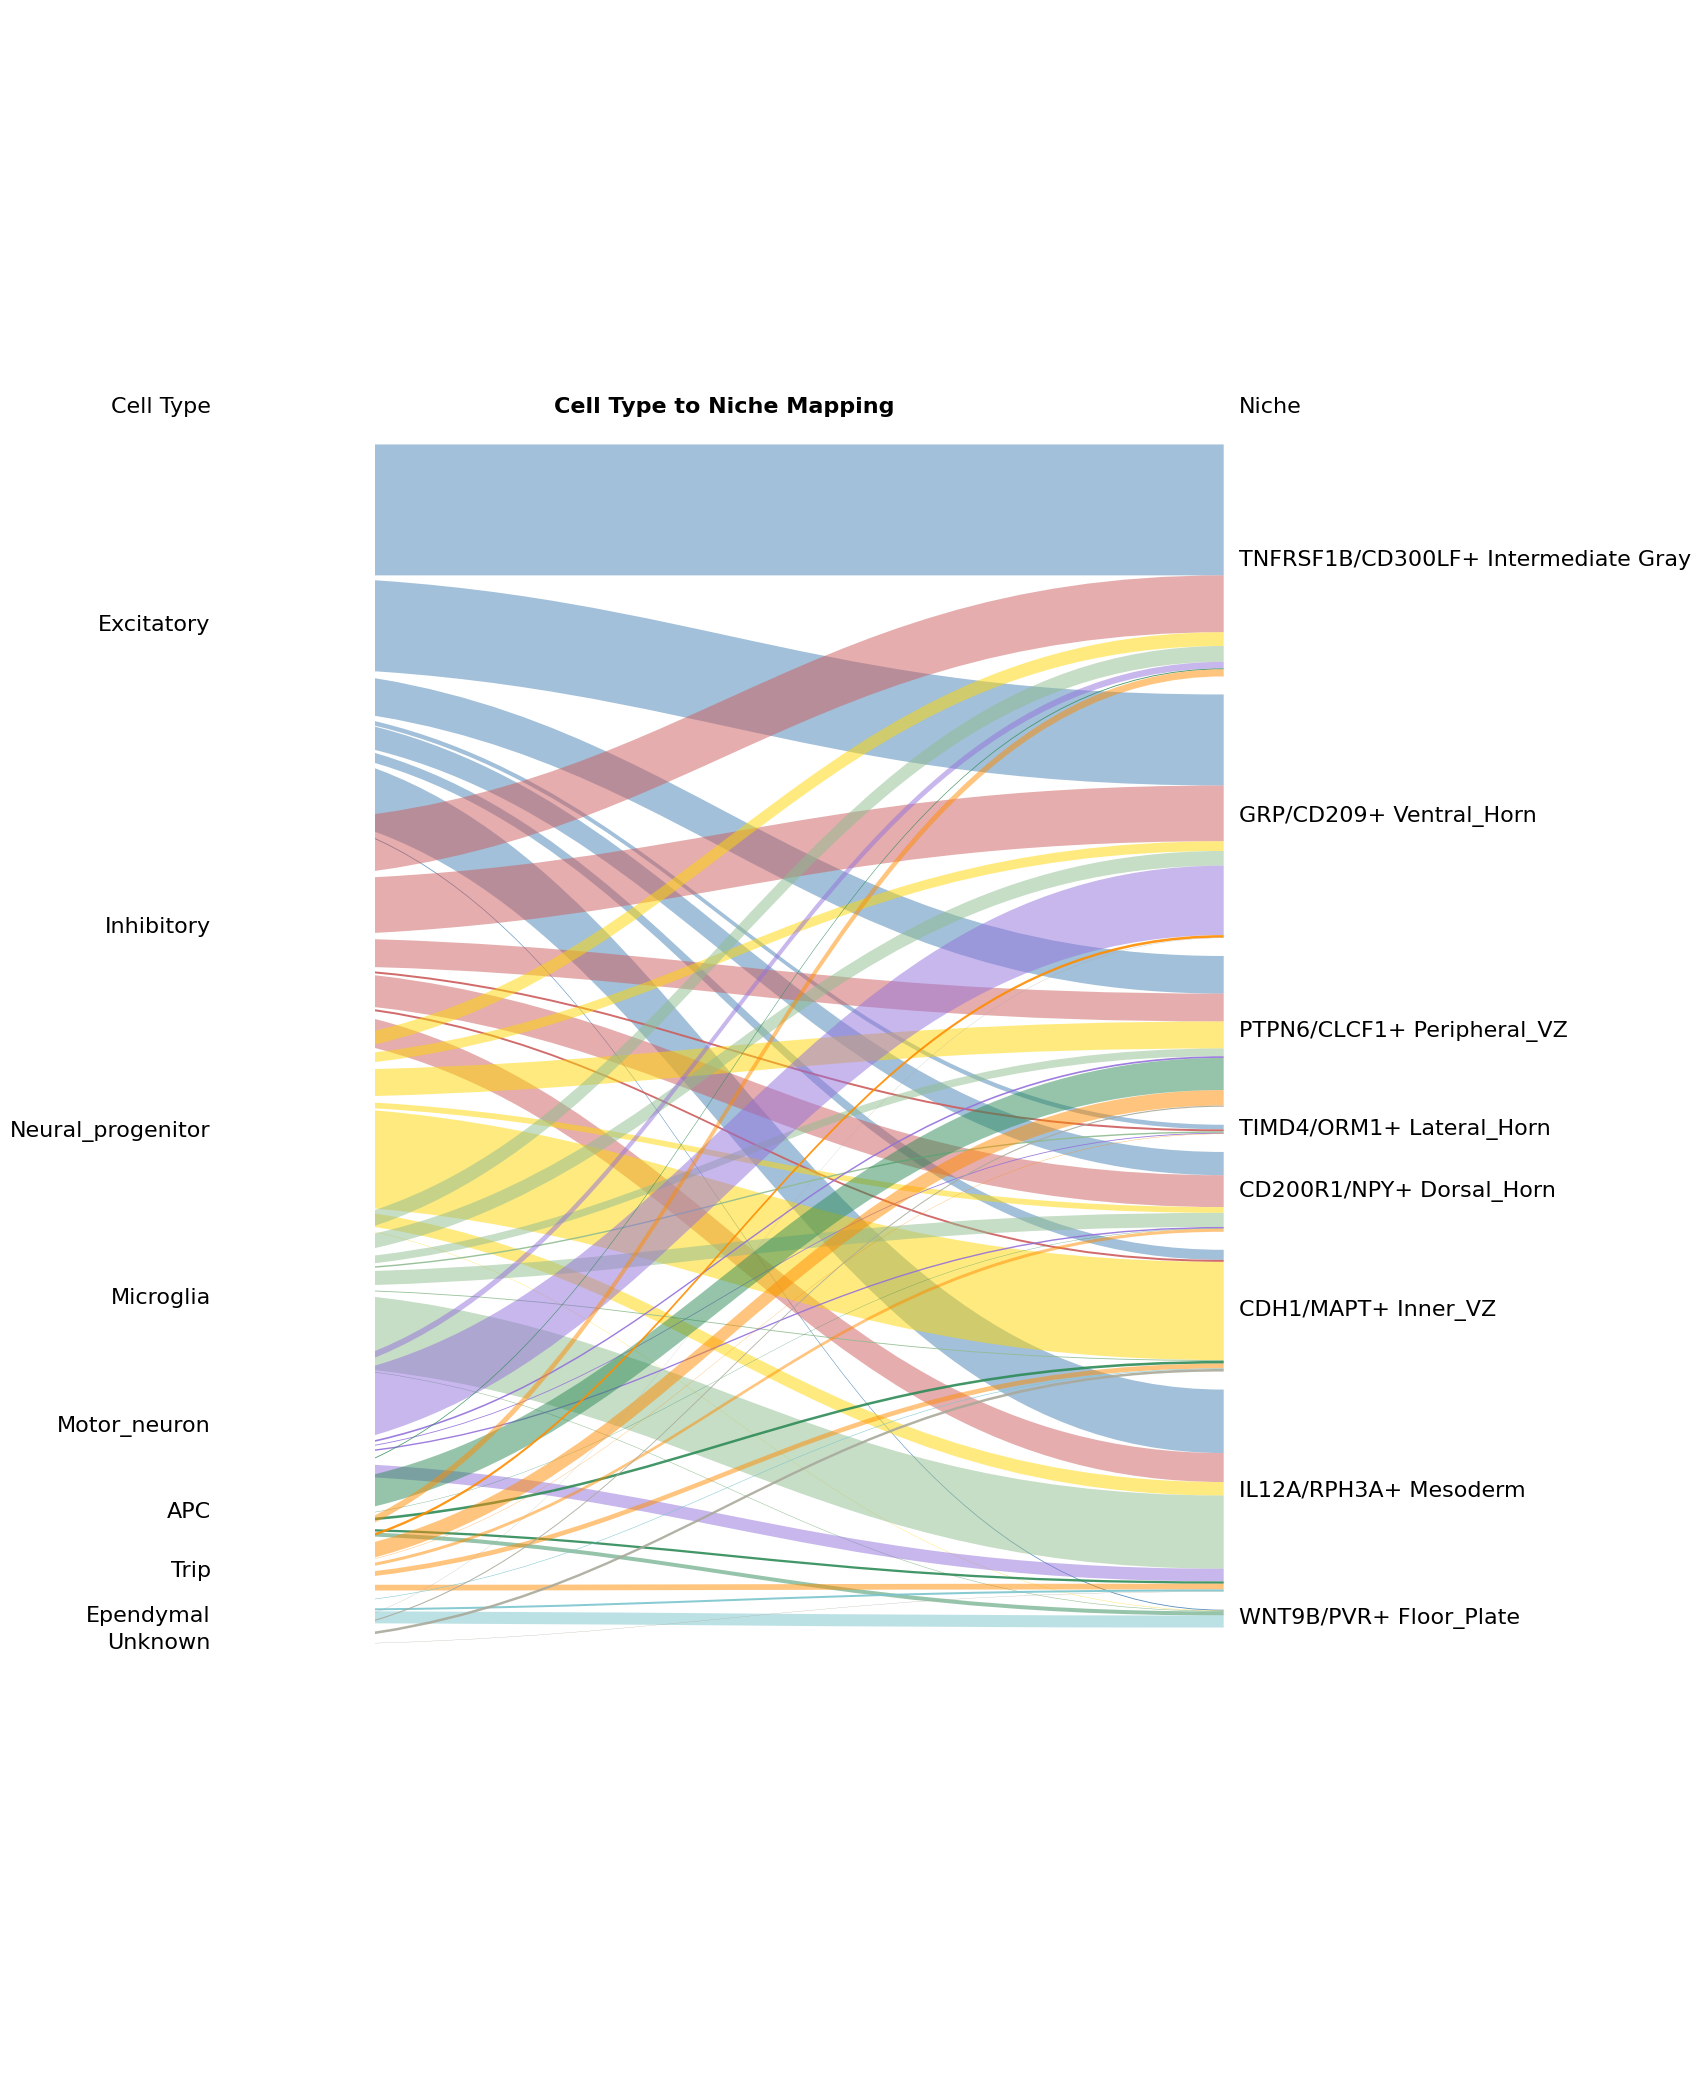

In [27]:
# sankey plot
fig, ax = plt.subplots(figsize=(17, 21))
sankey(
    x=model.adata.obs[cell_type_key],
    y=model.adata.obs["niche"],
    title="Cell Type to Niche Mapping",
    title_left="Cell Type",
    title_right="Niche",
    ax=ax,
    fontsize="16",  # "xx-small",
    #left_order=model.adata.obs[cell_type_key].unique().tolist(),
    colors=cell_type_colors,
    alpha=0.5)
plt.tight_layout()
plt.savefig(f"{figure_folder_path}/sankey_cell_type_to_niche.pdf")
plt.show()

#### 4.3.4 GP activities

In [28]:
# Visualize GP activities of enriched GPs across niches
df = model.adata.obs[["niche"] + enriched_gps].groupby("niche").mean()
scaler = MinMaxScaler()
normalized_columns = scaler.fit_transform(df)
normalized_df = pd.DataFrame(normalized_columns, columns=df.columns)
normalized_df.index = df.index
normalized_df

,WNT9B_combined_GP,ADAM29_ligand_receptor_target_gene_GP,GAST_combined_GP,Histamine_metabolite_enzyme_sensor_GP,EFNB3_combined_GP,CD320_ligand_receptor_target_gene_GP,GPI_ligand_receptor_target_gene_GP,PRSS1_combined_GP,NTS_combined_GP,PVR_ligand_receptor_target_gene_GP,...,Xanthine_metabolite_enzyme_sensor_GP,COL17A1_combined_GP,LGALS8_ligand_receptor_GP,LACRT_combined_GP,SI_ligand_receptor_target_gene_GP,PLA2G10_ligand_receptor_target_gene_GP,THBS1_combined_GP,WNT8A_combined_GP,Myristic acid_metabolite_enzyme_sensor_GP,GDF11_combined_GP
niche,,,,,,,,,,,,,,,,,,,,,
GRP/CD209+ Ventral_Horn,0.327349,0.707373,0.622332,0.256028,0.570337,0.171795,0.829394,0.860422,0.382217,0.384623,...,1.000000,0.868639,1.000000,0.700124,0.530172,0.984996,0.000000,0.197927,0.966736,0.572730
TNFRSF1B/CD300LF+ Intermediate Gray,0.000000,0.749054,0.935036,0.143933,0.960864,0.264561,0.859546,0.973635,0.099994,0.039116,...,0.844121,1.000000,0.000000,0.778169,0.410451,0.703140,0.503523,0.000000,1.000000,1.000000
IL12A/RPH3A+ Mesoderm,0.479234,0.829611,0.583718,0.409097,0.578342,0.192202,0.803800,0.612908,0.295827,0.379429,...,0.163812,0.274328,0.965556,0.304041,0.321448,0.709738,0.286105,1.000000,0.244498,0.322186
PTPN6/CLCF1+ Peripheral_VZ,0.509123,0.656863,0.496341,0.648281,0.773367,0.542646,0.517441,0.505731,0.434522,0.302019,...,0.136495,0.520510,0.171116,0.617198,0.327632,0.000000,0.720408,0.534627,0.000000,0.721406
CDH1/MAPT+ Inner_VZ,0.697995,0.836242,0.531883,0.621613,0.685826,0.657465,0.000000,0.559434,0.555971,0.430144,...,0.422711,0.220498,0.444510,0.446693,0.530785,0.036877,1.000000,0.827429,0.351066,0.461210
CD200R1/NPY+ Dorsal_Horn,0.171064,0.905761,0.818201,0.286410,1.000000,0.213095,0.820899,0.674359,0.146791,0.032370,...,0.000000,0.568139,0.258758,0.684050,0.041136,0.680616,0.643604,0.659356,0.349569,0.915453
WNT9B/PVR+ Floor_Plate,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.304821,0.000000,1.000000,1.000000,...,0.456688,0.000000,0.922961,0.000000,1.000000,0.406143,0.214942,0.781343,0.183493,0.000000
TIMD4/ORM1+ Lateral_Horn,0.006700,1.000000,1.000000,0.000000,0.921178,0.000000,1.000000,1.000000,0.000000,0.000000,...,0.522856,0.993314,0.681383,1.000000,0.000000,1.000000,0.327435,0.429357,0.870785,0.804153


In [29]:
# 自定义排序顺序
custom_order = [
    "CDH1/MAPT+ Inner_VZ",
    "PTPN6/CLCF1+ Peripheral_VZ",
    "WNT9B/PVR+ Floor_Plate",
    "CD200R1/NPY+ Dorsal_Horn",
    "IL12A/RPH3A+ Mesoderm",
    "TIMD4/ORM1+ Lateral_Horn",
    "GRP/CD209+ Ventral_Horn",
    "TNFRSF1B/CD300LF+ Intermediate Gray"
]

# 按自定义顺序重新排序索引
normalized_df = normalized_df.reindex(custom_order)
normalized_df

,WNT9B_combined_GP,ADAM29_ligand_receptor_target_gene_GP,GAST_combined_GP,Histamine_metabolite_enzyme_sensor_GP,EFNB3_combined_GP,CD320_ligand_receptor_target_gene_GP,GPI_ligand_receptor_target_gene_GP,PRSS1_combined_GP,NTS_combined_GP,PVR_ligand_receptor_target_gene_GP,...,Xanthine_metabolite_enzyme_sensor_GP,COL17A1_combined_GP,LGALS8_ligand_receptor_GP,LACRT_combined_GP,SI_ligand_receptor_target_gene_GP,PLA2G10_ligand_receptor_target_gene_GP,THBS1_combined_GP,WNT8A_combined_GP,Myristic acid_metabolite_enzyme_sensor_GP,GDF11_combined_GP
niche,,,,,,,,,,,,,,,,,,,,,
CDH1/MAPT+ Inner_VZ,0.697995,0.836242,0.531883,0.621613,0.685826,0.657465,0.000000,0.559434,0.555971,0.430144,...,0.422711,0.220498,0.444510,0.446693,0.530785,0.036877,1.000000,0.827429,0.351066,0.461210
PTPN6/CLCF1+ Peripheral_VZ,0.509123,0.656863,0.496341,0.648281,0.773367,0.542646,0.517441,0.505731,0.434522,0.302019,...,0.136495,0.520510,0.171116,0.617198,0.327632,0.000000,0.720408,0.534627,0.000000,0.721406
WNT9B/PVR+ Floor_Plate,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.304821,0.000000,1.000000,1.000000,...,0.456688,0.000000,0.922961,0.000000,1.000000,0.406143,0.214942,0.781343,0.183493,0.000000
CD200R1/NPY+ Dorsal_Horn,0.171064,0.905761,0.818201,0.286410,1.000000,0.213095,0.820899,0.674359,0.146791,0.032370,...,0.000000,0.568139,0.258758,0.684050,0.041136,0.680616,0.643604,0.659356,0.349569,0.915453
IL12A/RPH3A+ Mesoderm,0.479234,0.829611,0.583718,0.409097,0.578342,0.192202,0.803800,0.612908,0.295827,0.379429,...,0.163812,0.274328,0.965556,0.304041,0.321448,0.709738,0.286105,1.000000,0.244498,0.322186
TIMD4/ORM1+ Lateral_Horn,0.006700,1.000000,1.000000,0.000000,0.921178,0.000000,1.000000,1.000000,0.000000,0.000000,...,0.522856,0.993314,0.681383,1.000000,0.000000,1.000000,0.327435,0.429357,0.870785,0.804153
GRP/CD209+ Ventral_Horn,0.327349,0.707373,0.622332,0.256028,0.570337,0.171795,0.829394,0.860422,0.382217,0.384623,...,1.000000,0.868639,1.000000,0.700124,0.530172,0.984996,0.000000,0.197927,0.966736,0.572730
TNFRSF1B/CD300LF+ Intermediate Gray,0.000000,0.749054,0.935036,0.143933,0.960864,0.264561,0.859546,0.973635,0.099994,0.039116,...,0.844121,1.000000,0.000000,0.778169,0.410451,0.703140,0.503523,0.000000,1.000000,1.000000


In [30]:
# data from above
differential_gp_test_results_frame

,category,gene_program,p_h0,p_h1,log_bayes_factor
0,6,WNT9B_combined_GP,0.996796,0.003204,5.740218
1,6,ADAM29_ligand_receptor_target_gene_GP,0.003535,0.996465,-5.641555
2,6,GAST_combined_GP,0.003575,0.996425,-5.630193
3,6,Histamine_metabolite_enzyme_sensor_GP,0.996359,0.003641,5.611954
4,6,EFNB3_combined_GP,0.004030,0.995970,-5.509943
...,...,...,...,...,...
1019,3,Myristic acid_metabolite_enzyme_sensor_GP,0.090550,0.909450,-2.306943
1020,6,SLITRK1_combined_GP,0.909393,0.090607,2.306243
1021,1,IFNK_combined_GP,0.909211,0.090789,2.304042
1022,3,ACP4_ligand_receptor_target_gene_GP,0.090840,0.909160,-2.303420


In [31]:
differential_gp_test_results_frame['category'] = differential_gp_test_results_frame['category'].map(niche_annotation_dict)
differential_gp_test_results_frame

,category,gene_program,p_h0,p_h1,log_bayes_factor
0,WNT9B/PVR+ Floor_Plate,WNT9B_combined_GP,0.996796,0.003204,5.740218
1,WNT9B/PVR+ Floor_Plate,ADAM29_ligand_receptor_target_gene_GP,0.003535,0.996465,-5.641555
2,WNT9B/PVR+ Floor_Plate,GAST_combined_GP,0.003575,0.996425,-5.630193
3,WNT9B/PVR+ Floor_Plate,Histamine_metabolite_enzyme_sensor_GP,0.996359,0.003641,5.611954
4,WNT9B/PVR+ Floor_Plate,EFNB3_combined_GP,0.004030,0.995970,-5.509943
...,...,...,...,...,...
1019,PTPN6/CLCF1+ Peripheral_VZ,Myristic acid_metabolite_enzyme_sensor_GP,0.090550,0.909450,-2.306943
1020,WNT9B/PVR+ Floor_Plate,SLITRK1_combined_GP,0.909393,0.090607,2.306243
1021,TNFRSF1B/CD300LF+ Intermediate Gray,IFNK_combined_GP,0.909211,0.090789,2.304042
1022,PTPN6/CLCF1+ Peripheral_VZ,ACP4_ligand_receptor_target_gene_GP,0.090840,0.909160,-2.303420


In [32]:
# 将category列转换为有序分类类型
differential_gp_test_results_frame['category'] = pd.Categorical(differential_gp_test_results_frame['category'], 
                               categories=custom_order,
                               ordered=True)

# 按category排序后，再按p_h0降序排列
differential_gp = differential_gp_test_results_frame.sort_values(by=['category', 'p_h0'],
                          ascending=[True, False],
                          kind='mergesort')  # 保持排序稳定性
differential_gp

,category,gene_program,p_h0,p_h1,log_bayes_factor
24,CDH1/MAPT+ Inner_VZ,L-Glutamic acid_metabolite_enzyme_sensor_GP,0.990953,0.009047,4.696204
42,CDH1/MAPT+ Inner_VZ,CCL3_combined_GP,0.987615,0.012385,4.378791
51,CDH1/MAPT+ Inner_VZ,CDH1_ligand_receptor_target_gene_GP,0.986877,0.013123,4.320178
53,CDH1/MAPT+ Inner_VZ,MAPT_ligand_receptor_GP,0.986640,0.013360,4.302022
71,CDH1/MAPT+ Inner_VZ,ADAM11_ligand_receptor_target_gene_GP,0.984093,0.015907,4.124932
...,...,...,...,...,...
50,TNFRSF1B/CD300LF+ Intermediate Gray,LRRC4_ligand_receptor_target_gene_GP,0.013026,0.986974,-4.327726
44,TNFRSF1B/CD300LF+ Intermediate Gray,SOST_combined_GP,0.012543,0.987457,-4.365988
38,TNFRSF1B/CD300LF+ Intermediate Gray,COMPLEX:IL12A_IL12B_ligand_receptor_GP,0.012007,0.987993,-4.410210
30,TNFRSF1B/CD300LF+ Intermediate Gray,Aldosterone_metabolite_enzyme_sensor_GP,0.010299,0.989701,-4.565396


In [33]:
# 对数据框按category列分组，并选出每组中p_h0列最高的三行
top_rows_per_category = differential_gp.groupby('category').apply(
    lambda group: group.nlargest(5, 'p_h0')
).reset_index(drop=True)

top_rows_per_category['gene_program']

/tmp/ipykernel_1217938/2243529472.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_rows_per_category = differential_gp.groupby('category').apply(


0           L-Glutamic acid_metabolite_enzyme_sensor_GP
1                                      CCL3_combined_GP
2                   CDH1_ligand_receptor_target_gene_GP
3                               MAPT_ligand_receptor_GP
4                 ADAM11_ligand_receptor_target_gene_GP
5                              FGFR3_ligand_receptor_GP
6     Dihomo-gamma-linolenic acid_metabolite_enzyme_...
7                              PTPN6_ligand_receptor_GP
8                COMPLEX:CLCF1_CRLF1_ligand_receptor_GP
9                 MPIG6B_ligand_receptor_target_gene_GP
10                                    WNT9B_combined_GP
11                Histamine_metabolite_enzyme_sensor_GP
12                 CD320_ligand_receptor_target_gene_GP
13                                      NTS_combined_GP
14                   PVR_ligand_receptor_target_gene_GP
15                                    EFNA1_combined_GP
16                           CD200R1_ligand_receptor_GP
17                 Cortisol_metabolite_enzyme_se

In [34]:
top5 = normalized_df[top_rows_per_category['gene_program'].to_list()]
top5

,L-Glutamic acid_metabolite_enzyme_sensor_GP,CCL3_combined_GP,CDH1_ligand_receptor_target_gene_GP,MAPT_ligand_receptor_GP,ADAM11_ligand_receptor_target_gene_GP,FGFR3_ligand_receptor_GP,Dihomo-gamma-linolenic acid_metabolite_enzyme_sensor_GP,PTPN6_ligand_receptor_GP,COMPLEX:CLCF1_CRLF1_ligand_receptor_GP,MPIG6B_ligand_receptor_target_gene_GP,...,Androstenedione_metabolite_enzyme_sensor_GP,D-Glucose_metabolite_enzyme_sensor_GP,GRP_combined_GP,CD209_combined_GP,Ornithine_metabolite_enzyme_sensor_GP,L-Arginine_metabolite_enzyme_sensor_GP,TIMP1_ligand_receptor_target_gene_GP,TNFRSF1B_ligand_receptor_GP,PLB1_ligand_receptor_target_gene_GP,FSTL1_ligand_receptor_GP
niche,,,,,,,,,,,,,,,,,,,,,
CDH1/MAPT+ Inner_VZ,1.000000,1.000000,1.000000,1.000000,1.000000,0.807843,0.858113,0.620074,0.657107,0.472442,...,0.279214,0.254276,0.435031,0.428156,0.531833,0.414931,0.171617,0.389686,0.292184,0.486706
PTPN6/CLCF1+ Peripheral_VZ,0.517770,0.593644,0.484105,0.747166,0.600876,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.043104,0.000000,0.000000,0.480703,0.400389,0.510476,0.314660,0.496586
WNT9B/PVR+ Floor_Plate,0.717550,0.678915,0.393057,0.585510,0.480262,0.793786,0.753673,0.989003,0.594801,0.657496,...,0.356539,0.260908,0.496060,0.463899,0.516894,0.092494,0.000000,0.000000,0.000000,0.000000
CD200R1/NPY+ Dorsal_Horn,0.210269,0.227519,0.358719,0.445771,0.274457,0.734015,0.770397,0.599294,0.858328,0.544051,...,0.115337,0.112198,0.000000,0.108960,0.059626,0.421362,0.418553,0.534592,0.430331,0.376493
IL12A/RPH3A+ Mesoderm,0.479823,0.149860,0.322979,0.351021,0.149587,0.542355,0.507940,0.475984,0.505618,0.174682,...,0.467425,0.450089,0.527115,0.573764,0.447007,0.000000,0.039764,0.029572,0.054964,0.056426
TIMD4/ORM1+ Lateral_Horn,0.000000,0.000000,0.000000,0.000000,0.000000,0.108363,0.170088,0.000000,0.267811,0.041775,...,0.732358,0.722476,0.636553,0.687628,0.559670,0.403972,0.605634,0.455476,0.591704,0.458526
GRP/CD209+ Ventral_Horn,0.226002,0.128587,0.050726,0.002292,0.160914,0.000000,0.000000,0.115665,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.392256,0.596559,0.321240,0.528687,0.572136
TNFRSF1B/CD300LF+ Intermediate Gray,0.042060,0.310150,0.170002,0.155439,0.293086,0.311216,0.392441,0.259353,0.419420,0.550563,...,0.530628,0.529006,0.438056,0.482544,0.472169,1.000000,1.000000,1.000000,1.000000,1.000000


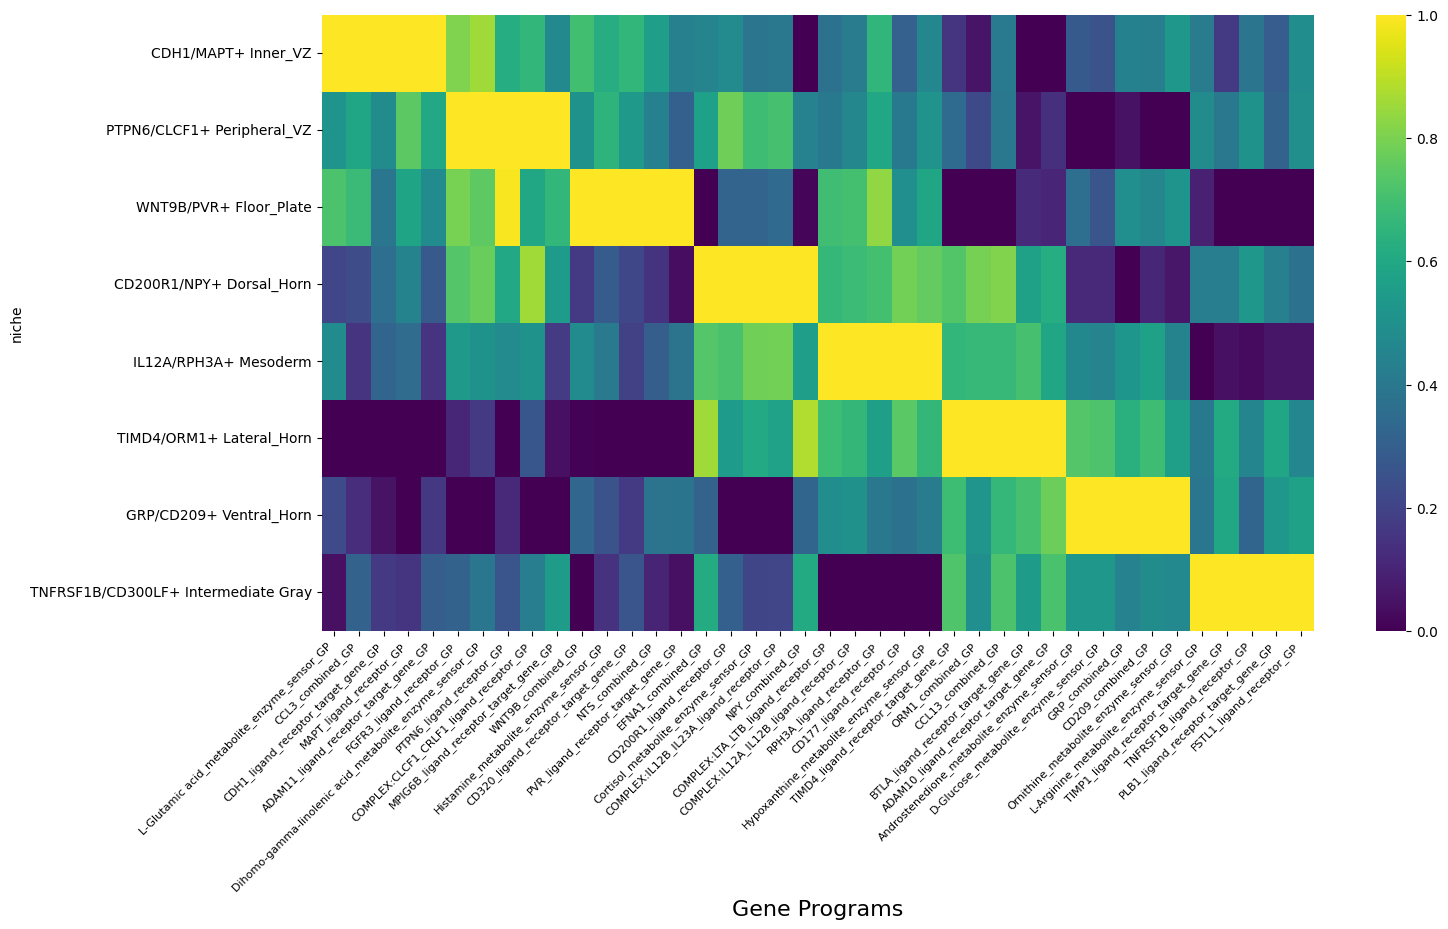

In [35]:

plt.figure(figsize=(16, 8))  # Set the figure size
ax = sns.heatmap(top5,
            cmap='viridis',
            annot=False,
            linewidths=0)
plt.xticks(rotation=45,
           fontsize=8,
           ha="right"
          )
plt.xlabel("Gene Programs", fontsize=16)
plt.savefig(f"{figure_folder_path}/enriched_top5_gps_heatmap.pdf",
            bbox_inches="tight")

In [36]:
# Store gene program summary of enriched gene programs
save_file = True
file_path = f"{figure_folder_path}/" \
            f"/log_bayes_factor_{log_bayes_factor_thresh}_" \
            "niche_enriched_gps_summary.csv"

gp_summary_cols = ["gp_name",
                   "n_source_genes",
                   "n_non_zero_source_genes",
                   "n_target_genes",
                   "n_non_zero_target_genes",
                   "gp_source_genes",
                   "gp_target_genes",
                   "gp_source_genes_importances",
                   "gp_target_genes_importances"]

enriched_gp_summary_df = gp_summary_df[gp_summary_df["gp_name"].isin(enriched_gps)]
cat_dtype = pd.CategoricalDtype(categories=enriched_gps, ordered=True)
enriched_gp_summary_df.loc[:, "gp_name"] = enriched_gp_summary_df["gp_name"].astype(cat_dtype)
enriched_gp_summary_df = enriched_gp_summary_df.sort_values(by="gp_name")
enriched_gp_summary_df = enriched_gp_summary_df[gp_summary_cols]

if save_file:
    enriched_gp_summary_df.to_csv(f"{file_path}")
else:
    display(enriched_gp_summary_df)

Now we will have a look at the GP activities and the log normalized counts of
the most important omics features of the differential GPs.

In [ ]:
plot_label = f"log_bayes_factor_{log_bayes_factor_thresh}_cluster_{selected_cats[0] if selected_cats else 'None'}_vs_rest"
save_figs = True

generate_enriched_gp_info_plots(
    plot_label=plot_label,
    model=model,
    sample_key=sample_key,
    differential_gp_test_results_key=differential_gp_test_results_key,
    cat_key="niche",
    cat_palette=latent_cluster_colors,
    n_top_enriched_gp_start_idx=0,
    n_top_enriched_gp_end_idx=10,
    feature_spaces=samples, # ["latent"]
    n_top_genes_per_gp=3,
    save_figs=save_figs,
    figure_folder_path=f"{figure_folder_path}/",
    spot_size=20)

#### 4.3.5 Cell-cell Communication

Now we will use the inferred activity of an enriched combined interaction GP to analyze the involved intercellular interactions.

如果不是多组织的数据，这个方法做的细胞通讯很一般

In [45]:
gp_name = "TNFRSF14_ligand_receptor_target_gene_GP"

In [47]:
network_df = compute_communication_gp_network(
    gp_list=[gp_name],
    model=model,
    group_key="niche",
    n_neighbors=n_neighbors)
network_df

,source,target,strength,strength_unscaled,edge_type


In [ ]:

visualize_communication_gp_network(
    adata=model.adata,
    network_df=network_df,
    figsize=(10, 7),
    cat_colors=latent_cluster_colors,
    edge_type_colors=["#1f77b4"], 
    cat_key=latent_cluster_key,
    save=True,
    save_path=f"{figure_folder_path}/gp_network_{gp_name}.pdf",
    )

#### 4.3.6 GO terms

In [8]:
file_path = f"{result_folder_path}/{dataset}_analysis.h5ad"
adata = sc.read_h5ad(file_path)

In [9]:
adata.obs['niche']

index
GW6:16560_16740             PTPN6/CLCF1+ Peripheral_VZ
GW6:15600_17310                    CDH1/MAPT+ Inner_VZ
GW6:16050_16650    TNFRSF1B/CD300LF+ Intermediate Gray
GW6:16860_17070                GRP/CD209+ Ventral_Horn
GW6:16590_16590    TNFRSF1B/CD300LF+ Intermediate Gray
                                  ...                 
GW6:16200_17970                  IL12A/RPH3A+ Mesoderm
GW6:15450_18060               CD200R1/NPY+ Dorsal_Horn
GW6:15360_17670                    CDH1/MAPT+ Inner_VZ
GW6:16320_18030                  IL12A/RPH3A+ Mesoderm
GW6:16410_18030                  IL12A/RPH3A+ Mesoderm
Name: niche, Length: 3681, dtype: category
Categories (8, object): ['GRP/CD209+ Ventral_Horn', 'TNFRSF1B/CD300LF+ Intermediate Gray', 'IL12A/RPH3A+ Mesoderm', 'PTPN6/CLCF1+ Peripheral_VZ', 'CDH1/MAPT+ Inner_VZ', 'CD200R1/NPY+ Dorsal_Horn', 'WNT9B/PVR+ Floor_Plate', 'TIMD4/ORM1+ Lateral_Horn']

In [ ]:
# 进行差异基因表达分析
sc.tl.rank_genes_groups(adata, groupby='niche', method='wilcoxon')
# 绘制一个总结图，展示每组前25个差异基因
sc.pl.rank_genes_groups(adata, n_genes=30, sharey=False)

In [23]:
marker_niche = sc.get.rank_genes_groups_df(adata, group=None, key = 'rank_genes_groups', log2fc_min =0.25, pval_cutoff=0.01)

In [17]:
marker_niche.to_csv(f"{result_folder_path}/marker_niche.csv", index=False)

In [24]:
marker_niche

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,GRP/CD209+ Ventral_Horn,NEFL,22.104948,3.692199,2.832604e-108,8.589023e-104
1,GRP/CD209+ Ventral_Horn,GAP43,17.206875,2.893836,2.358194e-66,2.383505e-62
2,GRP/CD209+ Ventral_Horn,NEFM,14.494092,3.283267,1.320367e-47,1.000904e-43
3,GRP/CD209+ Ventral_Horn,STMN2,9.539426,2.104017,1.436248e-21,3.959083e-18
4,GRP/CD209+ Ventral_Horn,PEBP1,9.150994,1.938660,5.641211e-20,1.315791e-16
...,...,...,...,...,...,...
247,WNT9B/PVR+ Floor_Plate,VIM,5.835993,2.418260,5.347110e-09,4.204018e-05
248,WNT9B/PVR+ Floor_Plate,SULF1,4.713772,6.831324,2.431721e-06,1.053352e-02
249,WNT9B/PVR+ Floor_Plate,IGFBP2,4.522266,3.167811,6.118097e-06,2.061255e-02
250,WNT9B/PVR+ Floor_Plate,NTN1,4.389273,5.544360,1.137303e-05,3.135028e-02


# Save Results

In [38]:
model_folder_path

'../../artifacts/stereo_seq_spinal_cord_gw7/models/single_sample/11052025_220810'

In [39]:
# Save trained model
model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="analysis.h5ad")

In [77]:
# Log normalize counts for cellxgene server
sc.pp.normalize_total(model.adata, target_sum=1e4)
sc.pp.log1p(model.adata)

# Store gp summary in adata
gp_summary = model.get_gp_summary()
for col in gp_summary.columns:
    gp_summary[col] = gp_summary[col].astype(str)
model.adata.uns["nichecompass_gp_summary"] = gp_summary

model.adata.write(f"{result_folder_path}/{dataset}_analysis.h5ad")

# figure from paper about Rong Fan's data

In [14]:
model.adata.uns[gp_names_key] = np.array([gp for gp in model.adata.uns[gp_names_key] if not "Add-on " in gp])
model.adata.uns[active_gp_names_key] = np.array([gp for gp in model.adata.uns[active_gp_names_key] if not "Add-on " in gp])
model.adata.uns[gp_names_key] = np.array([gp.replace(" ", "_") for gp in model.adata.uns[gp_names_key]])
model.adata.uns[active_gp_names_key] = np.array([gp.replace(" ", "_") for gp in model.adata.uns[active_gp_names_key]])

In [15]:
# Dataset-specific metadata
cell_type_df = pd.read_csv(f"{srt_data_gold_folder_path}/spatial_atac_rna_seq_mouse_brain_batch2_cell_type_annotations.csv", index_col=0)
cell_type_df.rename({"predicted.celltype": "celltype"}, axis=1, inplace=True)
cell_type_df.drop("ATAC_clusters", axis=1, inplace=True)
model.adata.obs = model.adata.obs.merge(cell_type_df, left_index=True, right_index=True, how="left")

In [16]:
# Check number of active gene programs
active_gps = model.get_active_gps()
print(f"Number of total gene programs: {len(model.adata.uns[gp_names_key])}.")
print(f"Number of active gene programs: {len(active_gps)}.")

gp_summary_df = model.get_gp_summary()
gp_summary_df[gp_summary_df["gp_active"] == True][20:]

samples = model.adata.obs[sample_key].unique().tolist()
model.add_active_gp_scores_to_obs()

Number of total gene programs: 1034.
Number of active gene programs: 620.


## 3. Analysis

### 3.1 Create Figures

In [ ]:
### Supplementary Fig. 24a ###
adata_all_genes = sc.read_h5ad(f"{srt_data_gold_folder_path}/spatial_atac_rna_seq_mouse_brain_batch2.h5ad")
fig, axs = plt.subplots(nrows=2,
                        ncols=2,
                        figsize=(15, 15))

# Lmo4 TF & Target Gene Peaks
color_map = "RdPu"
sc.pl.spatial(
    adata=adata_all_genes,
    color="Drd3",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Drd3",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[0, 0],
    show=False)

plt.show()
fig.savefig(f"{figure_folder_path}/drd3_expression.pdf",
            bbox_inches="tight")
del(adata_all_genes)

In [ ]:
### Supplementary Fig. 24b ###
sc.tl.leiden(adata=model.adata,
             resolution=latent_leiden_resolution,
             key_added=latent_cluster_key,
             neighbors_key=latent_key)
sc.tl.leiden(adata=model.adata,
             resolution=0.05,
             key_added=latent_cluster_key,
             restrict_to=(latent_cluster_key, ["7"]),
             neighbors_key=latent_key)
sc.tl.leiden(adata=model.adata,
             resolution=0.05,
             key_added=latent_cluster_key,
             restrict_to=(latent_cluster_key, ["8"]),
             neighbors_key=latent_key)
sc.tl.leiden(adata=model.adata,
             resolution=0.05,
             key_added=latent_cluster_key,
             restrict_to=(latent_cluster_key, ["6"]),
             neighbors_key=latent_key)

niche_annotation_dict = {
    "0":"Sox5/Taf1+ L5-L6",
    "1":"Foxa1/Id3+ L6a-L6b",
    "2":"Meis2/Ebf1+ STR_ACB_core",
    "3":"Hlf/Neurod2+ L1_L4_vasc_olg",
    "4":"Addon16/Irf8+ STR_caudoputamen_lateral",
    "5":"Nr1i3/Lmx1a+ L1-L4",
    "6,0":"Pax2/L-Glutamine+ L5-L6",
    "6,1":"Zbtb7a/Myf5+ L5",
    "7,0":"Gfi1b/Ep300+ STR_caudoputamen_medial",
    "7,1":"Neurog3/Nkx2-2+ Anterior_commisure",
    "8,0":"Pitx3/Cadm1+ STR_ACB_shell",
    "8,1":"Usf2/Lmo4+ islm_Major_island_of_Calleja",
    "9":"Nkx6-2/Nfya+ Corpus_callosum",
    "10":"Plxna2/Hoxb1+ L1-L3",
    "11":"Smad3/Col1a2+ Meninges",
    "12":"Klf10/Crx+ Lateral_septum_complex",
    "13":"Lmo2/Nkx6-1+ Lateral_septal_nucleus",
    "14":"L5-L6",
    "15":"Dach1/Pitx3+ STR_medial",
    "16":"Bcl11a/Brca1+ Lateral_ventricle"}

model.adata.obs["niche"] = model.adata.obs[latent_cluster_key].map(niche_annotation_dict)

latent_cluster_colors = create_new_color_dict(
    adata=model.adata,
    cat_key=latent_cluster_key)
latent_cluster_colors["7,0"] = "#7d87b9"
latent_cluster_colors["4"] = "#4a6fe3"
latent_cluster_colors["2"] = "#023fa5"
latent_cluster_colors["1"] = "#DAB6C4"
latent_cluster_colors["15"] = "#9EB9F3"
latent_cluster_colors["7,1"] = "#9D88A2"
latent_cluster_colors["13"] = "#FF9CDA"
latent_cluster_colors["8,1"] = "#CE5A57"
niche_colors = {niche: latent_cluster_colors[cluster] for cluster, niche in niche_annotation_dict.items()}

model.adata.obs["niche_abr"] = model.adata.obs["niche"].apply(lambda x: x.split("GP+ ")[1].replace(" ", "\n") if "GP+ " in x else x)

niche_abreviated_colors = {}
for key, value in niche_colors.items():
    if "GP+ " in key:
        niche_abreviated_colors[key.split("GP+ ")[1].replace(" ", "\n")] = value
    else:
        niche_abreviated_colors[key] = value
        
save_fig = True
file_path = f"{figure_folder_path}/res_{latent_leiden_resolution}_" \
            "niches_latent_physical_space.pdf"

plot_category_in_latent_and_physical_space(
    adata=model.adata,
    plot_label="Niches",
    cat_key="niche",
    groups=None,
    sample_key=sample_key,
    samples=samples,
    cat_colors=niche_colors,
    size=(720000 / len(model.adata)),
    spot_size=spot_size,
    save_fig=save_fig,
    file_path=file_path)

In [ ]:
### Supplementary Fig. 24c ###
sc.tl.dendrogram(adata=model.adata,
                 use_rep="nichecompass_latent",
                 linkage_method="ward",
                 groupby="niche")

fig, (ax) = plt.subplots(1, 1, figsize=(0.6, 2))
sc.pl.dendrogram(
    adata=model.adata,
    groupby="niche",
    orientation="left",
    ax=ax,
    save="_nichecompass_latent.pdf")
plt.show()
if os.path.exists(f"{figure_folder_path}/dendrogram_nichecompass_latent.pdf"):
    os.remove(f"{figure_folder_path}/dendrogram_nichecompass_latent.pdf")
shutil.move(f"./figures/dendrogram_nichecompass_latent.pdf", figure_folder_path)
shutil.rmtree("./figures/")

In [ ]:
### Supplementary Fig. 24d ###
gp_resign = True # True

gps = [ 
    "Foxa1_TF_target_genes_GP", "Id3_TF_target_genes_GP",
    "Plxna2_ligand_receptor_target_gene_GP", "Hoxb1_TF_target_genes_GP",
    "Sox5_TF_target_genes_GP", "Taf1_TF_target_genes_GP", # Xanthine_metabolite_enzyme_sensor_GP    
    "Zbtb7a_TF_target_genes_GP", "Myf5_TF_target_genes_GP",
    "Pax2_TF_target_genes_GP", "L-Glutamine_metabolite_enzyme_sensor_GP",
    "Nr1i3_TF_target_genes_GP", "Lmx1a_TF_target_genes_GP",
    "Hlf_TF_target_genes_GP", "Neurod2_TF_target_genes_GP",
    "Add-on_16_GP", "Irf8_TF_target_genes_GP",
    "Meis2_TF_target_genes_GP", "Ebf1_TF_target_genes_GP",
    "Gfi1b_TF_target_genes_GP", "Ep300_TF_target_genes_GP",
    "Nkx6-2_TF_target_genes_GP", "Nfya_TF_target_genes_GP",
    "Neurog3_TF_target_genes_GP", "Nkx2-2_TF_target_genes_GP",
    "Lmo2_TF_target_genes_GP", "Nkx6-1_TF_target_genes_GP",
    "Klf10_TF_target_genes_GP", "Crx_TF_target_genes_GP",
    "Smad3_TF_target_genes_GP", "Col1a2_ligand_receptor_target_gene_GP",
    "Bcl11a_TF_target_genes_GP", "Brca1_TF_target_genes_GP", # Draxin_ligand_receptor_target_gene_GP
    "Usf2_TF_target_genes_GP", "Lmo4_TF_target_genes_GP",
    "Pitx3_TF_target_genes_GP", "Cadm1_ligand_receptor_target_gene_GP",
    "Dach1_TF_target_genes_GP", "Pitx3_TF_target_genes_GP",
]

resign_gps = [
    "Taf1_TF_target_genes_GP",
    "Zbtb7a_TF_target_genes_GP",
    "Meis2_TF_target_genes_GP",
    "Ebf1_TF_target_genes_GP",
    "Neurod2_TF_target_genes_GP",
    "Nr1i3_TF_target_genes_GP",
    "Hlf_TF_target_genes_GP",
    "L-Glutamine_metabolite_enzyme_sensor_GP",
    "Gfi1b_TF_target_genes_GP",
    "Ep300_TF_target_genes_GP",
    "Pitx3_TF_target_genes_GP",
    "Cadm1_ligand_receptor_target_gene_GP",
    "Usf2_TF_target_genes_GP",
    "Lmo4_TF_target_genes_GP",
    "Rps19_ligand_receptor_target_gene_GP",
    "Nfya_TF_target_genes_GP",
    "Nkx6-2_TF_target_genes_GP",
    "Lmo2_TF_target_genes_GP",
    "Pitx3_TF_target_genes_GP",
    "Brca1_TF_target_genes_GP",
    "Bcl11a_TF_target_genes_GP",
    "Nkx6-1_TF_target_genes_GP",
    "Klf10_TF_target_genes_GP",
    "Dach1_TF_target_genes_GP",
    "Pitx3_TF_target_genes_GP"]

if gp_resign:
    for gp in resign_gps:
        model.adata.obs[gp] = -1 * model.adata.obs[gp]

df = model.adata.obs[["niche"] + gps].groupby("niche").mean()
df = df.reindex(model.adata.uns["dendrogram_niche"]["categories_ordered"][::-1])

scaler = MinMaxScaler()
normalized_columns = scaler.fit_transform(df)
normalized_df = pd.DataFrame(normalized_columns, columns=df.columns)
normalized_df.index = df.index
normalized_df.columns = [col.split("_lig")[0].split("_met")[0].split("_TF")[0].replace("Add-on_16_GP", "Addon16").replace("_acid", " acid") + " GP" for col in normalized_df.columns]

plt.figure(figsize=(16, 6))  # Set the figure size
ax = sns.heatmap(normalized_df,
            cmap='viridis',
            annot=False,
            linewidths=0)
plt.xticks(rotation=45,
           ha="right"
          )
plt.savefig(f"{figure_folder_path}/enriched_gps_heatmap.pdf",
            bbox_inches="tight")

plt.figure(figsize=(6, 3))  # Set the figure size
ax = sns.heatmap(normalized_df,
            cmap='viridis',
            annot=False,
            linewidths=0,
            cbar_kws={"orientation": "horizontal", "location": "bottom", "shrink": 0.4})
plt.xticks([])
plt.savefig(f"{figure_folder_path}/heatmap_colorbar.pdf",
            bbox_inches="tight")

In [ ]:
### Supplementary Fig. 24e ###
cell_type_colors = create_new_color_dict(
    adata=model.adata,
    color_palette=("cell_type_30"),
    cat_key=cell_type_key)
cell_type_colors["CA3GL"] = "#1f77b4"
cell_type_colors["D1MSN"] = "#ff7f0e"
cell_type_colors["LSXGA"] = "#279e68"
cell_type_colors["MXD"] = "#d62728"
cell_type_colors["STRGA"] = "#aa40fc"

tmp = pd.crosstab(model.adata.obs["niche"], model.adata.obs[cell_type_key], normalize='index')
tmp = tmp.reindex(model.adata.uns["dendrogram_niche"]["categories_ordered"][::])
ax = tmp.plot.barh(color=cell_type_colors, stacked=True, figsize=(4, 6)).legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.xlabel("Cell Type Proportions")
plt.savefig(f"{figure_folder_path}/niche_cell_type_proportions.pdf", bbox_inches='tight')

In [ ]:
### Supplementary Fig. 24f ###
fig, ax = plt.subplots(figsize=(17, 21))
sankey(
    x=model.adata.obs[cell_type_key],
    y=model.adata.obs["niche_abr"],
    title="Cell Type to Niche Mapping",
    title_left="Cell Type",
    title_right="Niche",
    ax=ax,
    fontsize="16",  # "xx-small",
    #left_order=model.adata.obs[cell_type_key].unique().tolist(),
    colors=cell_type_colors,
    alpha=0.5)
plt.tight_layout()
plt.savefig(f"{figure_folder_path}/sankey_cell_type_to_niche.pdf")
plt.show()

In [ ]:
### Supplementary Fig. 33a ###
fig, axs = plt.subplots(nrows=6,
                        ncols=2,
                        figsize=(25, 25))
color_map = "RdGy_r"
sc.pl.spatial(
    adata=model.adata,
    color="Usf2_TF_target_genes_GP",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Usf2 GP",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[0, 0],
    show=False)    
color_map = "RdPu"
sc.pl.spatial(
    adata=model.adata,
    color="Prkar2b",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Prkar2b",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[0, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Apc",
    use_raw=False,
    color_map=color_map,
    spot_size=spot_size,
    title=f"Apc",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[1, 0],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Pou2f1",
    use_raw=False,
    color_map=color_map,
    spot_size=spot_size,
    title="Pou2f1",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[1, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata_atac,
    color="chr18:34247310-34248119",
    use_raw=False,
    color_map=color_map,
    spot_size=spot_size,
    title=f"chr18:34247310-34248119",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[2, 0],
    show=False)
sc.pl.spatial(
    adata=model.adata_atac,
    color="chr1:165934747-165935645",
    use_raw=False,
    color_map=color_map,
    spot_size=spot_size,
    title=f"chr1:165934747-165935645",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[2, 1],
    show=False)    
plt.show()
fig.savefig(f"{figure_folder_path}/usf2_gp_genes.pdf",
            bbox_inches="tight")

fig, axs = plt.subplots(nrows=6,
                        ncols=2,
                        figsize=(25, 25))
color_map = "RdGy_r"
sc.pl.spatial(
    adata=model.adata,
    color="Cebpz_TF_target_genes_GP",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Cebpz GP",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[0, 0],
    show=False)    
color_map = "RdPu"
sc.pl.spatial(
    adata=model.adata,
    color="Cebpz",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Cebpz",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[0, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Col11a1",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Col11a1",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[1, 0],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Apc",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Apc",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[1, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata_atac,
    color="chr3:114030022-114030924",
    color_map=color_map,
    spot_size=spot_size,
    title=f"chr3:114030022-114030924",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[2, 0],
    show=False)
sc.pl.spatial(
    adata=model.adata_atac,
    color="chr18:34247310-34248119",
    color_map=color_map,
    spot_size=spot_size,
    title=f"chr18:34247310-34248119",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[2, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata_atac,
    color="chr11:53300121-53301011",
    color_map=color_map,
    spot_size=spot_size,
    title=f"chr11:53300121-53301011",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[3, 0],
    show=False)
plt.show()
fig.savefig(f"{figure_folder_path}/cebpz_gp_genes_peaks.pdf",
            bbox_inches="tight")

fig, axs = plt.subplots(nrows=6,
                        ncols=2,
                            figsize=(25, 25))
model.adata.obs["Rela_TF_target_genes_GP_sign_corrected"] = -1 * model.adata.obs["Rela_TF_target_genes_GP"]
color_map = "RdGy_r"
sc.pl.spatial(
    adata=model.adata,
    color="Rela_TF_target_genes_GP_sign_corrected",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Rela GP",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[0, 0],
    show=False)    
color_map = "RdPu"
sc.pl.spatial(
    adata=model.adata,
    color="Bclaf1",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Bclaf1",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[0, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Ing4",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Ing4",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[1, 0],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Kmt2a",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Kmt2a",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[1, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata_atac,
    color="chr10:20311949-20312805",
    color_map=color_map,
    spot_size=spot_size,
    title=f"chr10:20311949-20312805",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[2, 0],
    show=False)
plt.show()
fig.savefig(f"{figure_folder_path}/rela_gp_genes_peaks.pdf",
            bbox_inches="tight")

fig, axs = plt.subplots(nrows=6,
                        ncols=2,
                        figsize=(25, 25))
model.adata.obs["Rarb_TF_target_genes_GP_sign_corrected"] = -1 * model.adata.obs["Rarb_TF_target_genes_GP"]
color_map = "RdGy_r"
sc.pl.spatial(
    adata=model.adata,
    color="Rarb_TF_target_genes_GP_sign_corrected",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Rarb GP",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[0, 0],
    show=False)    
color_map = "RdPu"
sc.pl.spatial(
    adata=model.adata,
    color="Isl1",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Isl1",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[0, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Hap1",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Hap1",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[1, 0],
    show=False)
sc.pl.spatial(
    adata=model.adata_atac,
    color="chr13:116304790-116305726",
    color_map=color_map,
    spot_size=spot_size,
    title=f"chr13:116304790-116305726",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[1, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata_atac,
    color="chr13:116309366-116310250",
    color_map=color_map,
    spot_size=spot_size,
    title=f"chr13:116309366-116310250",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[2, 0],
    show=False)
plt.show()
fig.savefig(f"{figure_folder_path}/rarb_gp_genes_peaks.pdf",
            bbox_inches="tight")

fig, axs = plt.subplots(nrows=6,
                        ncols=2,
                        figsize=(25, 25))
model.adata.obs["Rreb1_TF_target_genes_GP_sign_corrected"] = -1 * model.adata.obs["Rreb1_TF_target_genes_GP"]
color_map = "RdGy_r"
sc.pl.spatial(
    adata=model.adata,
    color="Rreb1_TF_target_genes_GP_sign_corrected",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Rreb1 GP",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[0, 0],
    show=False)    
color_map = "RdPu"
sc.pl.spatial(
    adata=model.adata,
    color="Rreb1",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Rreb1",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[0, 1],
    show=False)
plt.show()
fig.savefig(f"{figure_folder_path}/rreb1_gp_genes_peaks.pdf",
            bbox_inches="tight")

fig, axs = plt.subplots(nrows=6,
                        ncols=2,
                        figsize=(25, 25))
model.adata.obs["Gata1_TF_target_genes_GP_sign_corrected"] = -1 * model.adata.obs["Gata1_TF_target_genes_GP"]
color_map = "RdGy_r"
sc.pl.spatial(
    adata=model.adata,
    color="Gata1_TF_target_genes_GP_sign_corrected",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Gata1 GP",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[0, 0],
    show=False)    
color_map = "RdPu"
sc.pl.spatial(
    adata=model.adata,
    color="Tac1",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Tac1",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[0, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Runx1t1",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Runx1t1",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[1, 0],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Furin",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Furin",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[1, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata_atac,
    color="chr12:104689761-104690616",
    color_map=color_map,
    spot_size=spot_size,
    title=f"chr12:104689761-104690616",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[2, 0],
    show=False)
plt.show()
fig.savefig(f"{figure_folder_path}/Gata1_gp_genes_peaks.pdf",
            bbox_inches="tight")

fig, axs = plt.subplots(nrows=6,
                        ncols=2,
                        figsize=(25, 25))
color_map = "RdGy_r"
sc.pl.spatial(
    adata=model.adata,
    color="Lmo4_TF_target_genes_GP",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Lmo4",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[0, 0],
    show=False)    
color_map = "RdPu"
sc.pl.spatial(
    adata=model.adata,
    color="Lmo4",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Lmo4",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[0, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata_atac,
    color="chr11:70029079-70029942",
    use_raw=False,
    color_map=color_map,
    spot_size=spot_size,
    title=f"chr11:70029079-70029942",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[1, 0],
    show=False)
sc.pl.spatial(
    adata=model.adata_atac,
    color="chr11:70021137-70021886",
    use_raw=False,
    color_map=color_map,
    spot_size=spot_size,
    title="chr11:70021137-70021886",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[1, 1],
    show=False)
plt.show()
fig.savefig(f"{figure_folder_path}/lmo4_gp_genes_peaks.pdf",
            bbox_inches="tight")

In [ ]:
### Supplementary Fig. 33b ###
fig, axs = plt.subplots(nrows=6,
                        ncols=2,
                        figsize=(25, 25))
model.adata.obs["Add-on_89_GP_sign_corrected"] = -1 * model.adata.obs["Add-on_89_GP"]
color_map = "RdGy_r"
sc.pl.spatial(
    adata=model.adata,
    color="Add-on_89_GP_sign_corrected",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Add-on_89_GP",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[0, 0],
    show=False)    
color_map = "RdPu"
sc.pl.spatial(
    adata=model.adata_atac,
    color="chr13:9583665-9584550",
    color_map=color_map,
    spot_size=spot_size,
    title=f"chr13:9583665-9584550",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[0, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata_atac,
    color="chr9:104796453-104797222",
    color_map=color_map,
    spot_size=spot_size,
    title=f"chr9:104796453-104797222",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[1, 0],
    show=False)
sc.pl.spatial(
    adata=model.adata_atac,
    color="chr1:170358844-170359717",
    color_map=color_map,
    spot_size=spot_size,
    title=f"chr1:170358844-170359717",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[1, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata_atac,
    color="chr5:65770160-65771077",
    color_map=color_map,
    spot_size=spot_size,
    title=f"chr5:65770160-65771077",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[2, 0],
    show=False)
sc.pl.spatial(
    adata=model.adata_atac,
    color="chr2:156658586-156659426",
    color_map=color_map,
    spot_size=spot_size,
    title=f"chr2:156658586-156659426",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[2, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata_atac,
    color="chr13:102943643-102944509",
    color_map=color_map,
    spot_size=spot_size,
    title=f"chr13:102943643-102944509",
    use_raw=False,
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[3, 0],
    show=False)
plt.show()
fig.savefig(f"{figure_folder_path}/add-on89_gp_genes_peaks.pdf",
            bbox_inches="tight")

In [ ]:
### Supplementary Fig. 34a ###
fig, axs = plt.subplots(nrows=6,
                        ncols=2,
                            figsize=(25, 25))
#model.adata.obs["Nfya_TF_target_genes_GP_sign_corrected"] = -1 * model.adata.obs["Nfya_TF_target_genes_GP"]
color_map = "RdGy_r"
sc.pl.spatial(
    adata=model.adata,
    color="Nfya_TF_target_genes_GP",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Nfya GP",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[0, 0],
    show=False)    
color_map = "RdPu"
sc.pl.spatial(
    adata=model.adata,
    color="Cldn11",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Cldn11",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[0, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Phgdh",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Phgdh",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[1, 0],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Hmgcs1",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Hmgcs1",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[1, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Fdps",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Fdps",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[2, 0],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Ldlr",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Ldlr",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[2, 1],
    show=False)
plt.show()
fig.savefig(f"{figure_folder_path}/nfya_gp_genes_peaks.pdf",
            bbox_inches="tight")

fig, axs = plt.subplots(nrows=6,
                        ncols=2,
                        figsize=(25, 25))
model.adata.obs["Klf6_TF_target_genes_GP_sign_corrected"] = -1 * model.adata.obs["Klf6_TF_target_genes_GP"]
color_map = "RdGy_r"
sc.pl.spatial(
    adata=model.adata,
    color="Klf6_TF_target_genes_GP_sign_corrected",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Klf6 GP",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[0, 0],
    show=False)    
color_map = "RdPu"
sc.pl.spatial(
    adata=model.adata,
    color="Cers2",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Cers2",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[0, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Gstp2",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Gstp2",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[1, 0],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Gstp1",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Gstp1",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[1, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Tuba1a",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Tuba1a",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[2, 0],
    show=False)
plt.show()
fig.savefig(f"{figure_folder_path}/klf6_gp_genes_peaks.pdf",
            bbox_inches="tight")

fig, axs = plt.subplots(nrows=6,
                        ncols=2,
                        figsize=(25, 25))
color_map = "RdGy_r"
sc.pl.spatial(
    adata=model.adata,
    color="Tp73_TF_target_genes_GP",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Tp73 GP",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[0, 0],
    show=False)    
color_map = "RdPu"
sc.pl.spatial(
    adata=model.adata,
    color="Apod",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Apod",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[0, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Cryab",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Cryab",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[1, 0],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Gstp2",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Gstp2",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[1, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Gstp1",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Gstp1",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[2, 0],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Ybx1",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Ybx1",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[2, 1],
    show=False)
plt.show()
fig.savefig(f"{figure_folder_path}/tp73_gp_genes_peaks.pdf",
            bbox_inches="tight")

fig, axs = plt.subplots(nrows=6,
                        ncols=2,
                        figsize=(25, 25))
color_map = "RdGy_r"
sc.pl.spatial(
    adata=model.adata,
    color="Rps19_ligand_receptor_target_gene_GP",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Rps19 GP",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[0, 0],
    show=False)    
color_map = "RdPu"
sc.pl.spatial(
    adata=model.adata,
    color="Rps19",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Rps19",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[0, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Cd82",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Cd82",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[1, 0],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Scd2",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Scd2",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[1, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Ndrg1",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Ndrg1",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[2, 0],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Enpp2",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Enpp2",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[2, 1],
    show=False)
plt.show()
fig.savefig(f"{figure_folder_path}/rps19_gp_genes_peaks.pdf",
            bbox_inches="tight")

fig, axs = plt.subplots(nrows=6,
                        ncols=2,
                        figsize=(25, 25))
color_map = "RdGy_r"
sc.pl.spatial(
    adata=model.adata,
    color="Nkx6-2_TF_target_genes_GP",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Nkx6-2 GP",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[0, 0],
    show=False)    
color_map = "RdPu"
sc.pl.spatial(
    adata=model.adata,
    color="Plp1",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Plp1",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[0, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Mbp",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Mbp",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[1, 0],
    show=False)
plt.show()
fig.savefig(f"{figure_folder_path}/nkx6-2_gp_genes_peaks.pdf",
            bbox_inches="tight")

fig, axs = plt.subplots(nrows=6,
                        ncols=2,
                        figsize=(25, 25))
color_map = "RdGy_r"
sc.pl.spatial(
    adata=model.adata,
    color="Nkx2-2_TF_target_genes_GP",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Nkx2-2 GP",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[0, 0],
    show=False)    
color_map = "RdPu"
sc.pl.spatial(
    adata=model.adata,
    color="Ermn",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Ermn",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[0, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Sirt2",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Sirt2",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[1, 0],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Arx",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Arx",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[1, 1],
    show=False)
plt.show()
fig.savefig(f"{figure_folder_path}/nkx2-2_gp_genes_peaks.pdf",
            bbox_inches="tight")

fig, axs = plt.subplots(nrows=6,
                        ncols=2,
                        figsize=(25, 25))
model.adata.obs["Olig2_TF_target_genes_GP_sign_corrected"] = -1 * model.adata.obs["Olig2_TF_target_genes_GP"]
color_map = "RdGy_r"
sc.pl.spatial(
    adata=model.adata,
    color="Olig2_TF_target_genes_GP_sign_corrected",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Olig2  GP",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[0, 0],
    show=False)    
color_map = "RdPu"
sc.pl.spatial(
    adata=model.adata,
    color="Olig1",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Olig1",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[0, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Sox10",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Sox10",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[1, 0],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Olig2",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Olig2",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[1, 1],
    show=False)
plt.show()
fig.savefig(f"{figure_folder_path}/olig2_gp_genes_peaks.pdf",
            bbox_inches="tight")

fig, axs = plt.subplots(nrows=6,
                        ncols=2,
                        figsize=(25, 25))
model.adata.obs["Cd82_ligand_receptor_target_gene_GP_sign_corrected"] = -1 * model.adata.obs["Cd82_ligand_receptor_target_gene_GP"]
color_map = "RdGy_r"
sc.pl.spatial(
    adata=model.adata,
    color="Cd82_ligand_receptor_target_gene_GP_sign_corrected",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Cd82  GP",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[0, 0],
    show=False)    
color_map = "RdPu"
sc.pl.spatial(
    adata=model.adata,
    color="Cd82",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Cd82",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[0, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Gsn",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Gsn",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[1, 0],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Gfra1",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Gfra1",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[1, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Tcf7l2",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Tcf7l2",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[2, 0],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Zfp36l1",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Zfp36l1",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[2, 1],
    show=False)
plt.show()
fig.savefig(f"{figure_folder_path}/cd82_gp_genes_peaks.pdf",
            bbox_inches="tight")

fig, axs = plt.subplots(nrows=6,
                        ncols=2,
                        figsize=(25, 25))
color_map = "RdGy_r"
sc.pl.spatial(
    adata=model.adata,
    color="Nfasc_ligand_receptor_target_gene_GP",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Nfasc  GP",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[0, 0],
    show=False)    
color_map = "RdPu"
sc.pl.spatial(
    adata=model.adata,
    color="Nfasc",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Nfasc",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[0, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Mgll",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Mgll",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[1, 0],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Enpp2",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Enpp2",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[1, 1],
    show=False)
plt.show()
fig.savefig(f"{figure_folder_path}/nfasc_gp_genes_peaks.pdf",
            bbox_inches="tight")

fig, axs = plt.subplots(nrows=6,
                        ncols=2,
                        figsize=(25, 25))
model.adata.obs["Glycine_metabolite_enzyme_sensor_GP_sign_corrected"] = -1 * model.adata.obs["Glycine_metabolite_enzyme_sensor_GP"]
color_map = "RdGy_r"
sc.pl.spatial(
    adata=model.adata,
    color="Glycine_metabolite_enzyme_sensor_GP_sign_corrected",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Glycine  GP",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[0, 0],
    show=False)    
color_map = "RdPu"
sc.pl.spatial(
    adata=model.adata,
    color="Lap3",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Lap3",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[0, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Gatm",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Gatm",
    legend_loc=None,
    colorbar_loc="bottom",
    use_raw=False,
    ax=axs[1, 0],
    show=False)
plt.show()
fig.savefig(f"{figure_folder_path}/glycine_gp_genes_peaks.pdf",
            bbox_inches="tight")

In [ ]:
### Supplementary Fig. 34b ###
fig, axs = plt.subplots(nrows=5,
                        ncols=2,
                        figsize=(25, 25))
color_map = "RdGy_r"
sc.pl.spatial(
    adata=model.adata,
    color="Add-on_89_GP",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Add-on 89",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[0, 0],
    show=False)    
color_map = "RdPu"
sc.pl.spatial(
    adata=model.adata,
    color="Mobp",
    color_map=color_map,
    spot_size=spot_size,
    title=f"Mobp",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[0, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Tspan2",
    use_raw=False,
    color_map=color_map,
    spot_size=spot_size,
    title=f"Tspan2",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[1, 0],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Pllp",
    use_raw=False,
    color_map=color_map,
    spot_size=spot_size,
    title="Pllp",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[1, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Trf",
    use_raw=False,
    color_map=color_map,
    spot_size=spot_size,
    title="Trf",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[2, 0],
    show=False)
sc.pl.spatial(
    adata=model.adata,
    color="Pdlim2",
    use_raw=False,
    color_map=color_map,
    spot_size=spot_size,
    title="Pdlim2",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[2, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata_atac,
    color="chr1:24612403-24613300",
    use_raw=False,
    color_map=color_map,
    spot_size=spot_size,
    title=f"chr1:24612403-24613300",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[3, 0],
    show=False)
sc.pl.spatial(
    adata=model.adata_atac,
    color="chr1:172349675-172350564",
    use_raw=False,
    color_map=color_map,
    spot_size=spot_size,
    title="chr1:172349675-172350564",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[3, 1],
    show=False)
sc.pl.spatial(
    adata=model.adata_atac,
    color="chr4:48629122-48629953",
    use_raw=False,
    color_map=color_map,
    spot_size=spot_size,
    title="chr4:48629122-48629953",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[4, 0],
    show=False)
sc.pl.spatial(
    adata=model.adata_atac,
    color="chr14:54935868-54936644",
    use_raw=False,
    color_map=color_map,
    spot_size=spot_size,
    title="chr14:54935868-54936644",
    legend_loc=None,
    colorbar_loc="bottom",
    ax=axs[4, 1],
    show=False)
plt.show()
fig.savefig(f"{figure_folder_path}/addon89_gp_genes_peaks.pdf",
            bbox_inches="tight")

### 3.2 Save Results

In [42]:
# Log normalize counts for cellxgene server
sc.pp.normalize_total(model.adata, target_sum=1e4)
sc.pp.log1p(model.adata)
    
# Store gp summary in adata
gp_summary = model.get_gp_summary()
for col in gp_summary.columns:
    gp_summary[col] = gp_summary[col].astype(str)
model.adata.uns["nichecompass_gp_summary"] = gp_summary

model.adata.write(f"{result_folder_path}/{dataset}_analysis.h5ad")